<a href="https://colab.research.google.com/github/Shankey98/project_file/blob/main/%ED%99%94%EC%84%B1%EC%8B%9C_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EA%B3%B5%EB%AA%A8%EC%A0%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **인구 데이터 분석**


In [1]:
import pandas as pd
import os
from IPython.display import display, IFrame
import folium
import random
import pandas as pd
from pyproj import Proj, transform
import geopandas as gpd

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = r'C:\Users\SEUNGJUN\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
print(font_name)

NanumBarunGothic


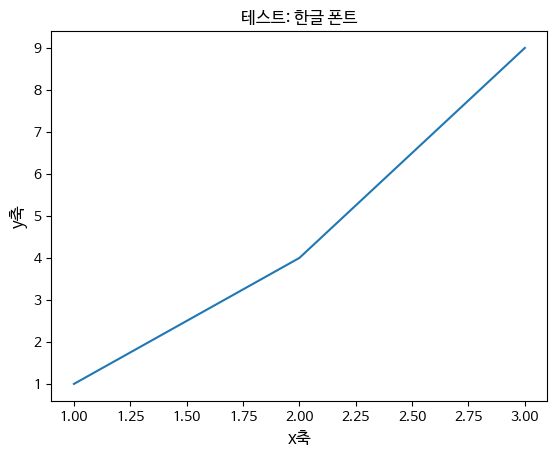

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

font_path = r'G:\내 드라이브\화성 데이터 공모전\데이터파일\나눔바른고딕\NanumFontSetup_TTF_BARUNGOTHIC\NanumBarunGothic.ttf'  # 파일명 확인!
fontprop = fm.FontProperties(fname=font_path, size=12)

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

plt.plot([1,2,3], [1,4,9])
plt.title('테스트: 한글 폰트', fontproperties=fontprop)
plt.xlabel('x축', fontproperties=fontprop)
plt.ylabel('y축', fontproperties=fontprop)
plt.show()

In [4]:
file_path = r'G:\내 드라이브\화성 데이터 공모전\데이터파일\경기도 화성시_인구_20231107.csv'
df_pop = pd.read_csv(file_path, encoding='cp949')
df_pop.drop(df_pop.index[-1],inplace=True) # 마지막 행 삭제
df_pop = df_pop[['행정구역', '인구수']]  # '행정구역'과 '인구수' 열만 선택
df_pop

,행정구역,인구수
0,봉담읍,92823.0
1,우정읍,17439.0
2,향남읍,85647.0
3,남양읍,55133.0
4,매송면,6742.0
5,비봉면,7009.0
6,마도면,6854.0
7,송산면,10830.0
8,서신면,7114.0
9,팔탄면,9894.0


In [5]:
# 5. 화성시 데이터 필터링
# 인구 데이터의 행정구역 이름에 '경기도 화성시' 접두사 추가
df_pop['행정구역'] = '경기도 화성시 ' + df_pop['행정구역']
df_pop

,행정구역,인구수
0,경기도 화성시 봉담읍,92823.0
1,경기도 화성시 우정읍,17439.0
2,경기도 화성시 향남읍,85647.0
3,경기도 화성시 남양읍,55133.0
4,경기도 화성시 매송면,6742.0
5,경기도 화성시 비봉면,7009.0
6,경기도 화성시 마도면,6854.0
7,경기도 화성시 송산면,10830.0
8,경기도 화성시 서신면,7114.0
9,경기도 화성시 팔탄면,9894.0


In [6]:
file_path_boundary = r'G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson'
df_boundary = gpd.read_file(file_path_boundary, delimiter='\t', encoding='utf-8')
df_boundary
# GeoJSON 파일에서 'adm_nm' 열을 기준으로 화성시 관련 데이터 필터링
df_hwaseong_boundary = df_boundary[df_boundary['adm_nm'].str.contains('화성시')].reset_index(drop=True)
df_hwaseong_boundary

c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DELIMITER
  return ogr_read(


,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,geometry
0,경기도 화성시 봉담읍,4159025300,41590,41,경기도,화성시,31240120,"MULTIPOLYGON (((126.97039 37.2292, 126.97091 3..."
1,경기도 화성시 우정읍,4159025600,41590,41,경기도,화성시,31240130,"MULTIPOLYGON (((126.55815 37.06117, 126.55367 ..."
2,경기도 화성시 향남읍,4159025900,41590,41,경기도,화성시,31240140,"MULTIPOLYGON (((126.99914 37.12364, 126.9981 3..."
3,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,"MULTIPOLYGON (((126.84097 37.26592, 126.83923 ..."
4,경기도 화성시 매송면,4159031000,41590,41,경기도,화성시,31240310,"MULTIPOLYGON (((126.92737 37.2788, 126.92759 3..."
5,경기도 화성시 비봉면,4159032000,41590,41,경기도,화성시,31240330,"MULTIPOLYGON (((126.91237 37.2386, 126.91239 3..."
6,경기도 화성시 마도면,4159033000,41590,41,경기도,화성시,31240350,"MULTIPOLYGON (((126.78641 37.23298, 126.78706 ..."
7,경기도 화성시 송산면,4159034000,41590,41,경기도,화성시,31240360,"MULTIPOLYGON (((126.65837 37.20181, 126.65827 ..."
8,경기도 화성시 서신면,4159035000,41590,41,경기도,화성시,31240370,"MULTIPOLYGON (((126.61494 37.11967, 126.61497 ..."
9,경기도 화성시 팔탄면,4159036000,41590,41,경기도,화성시,31240380,"MULTIPOLYGON (((126.8999 37.19404, 126.90113 3..."


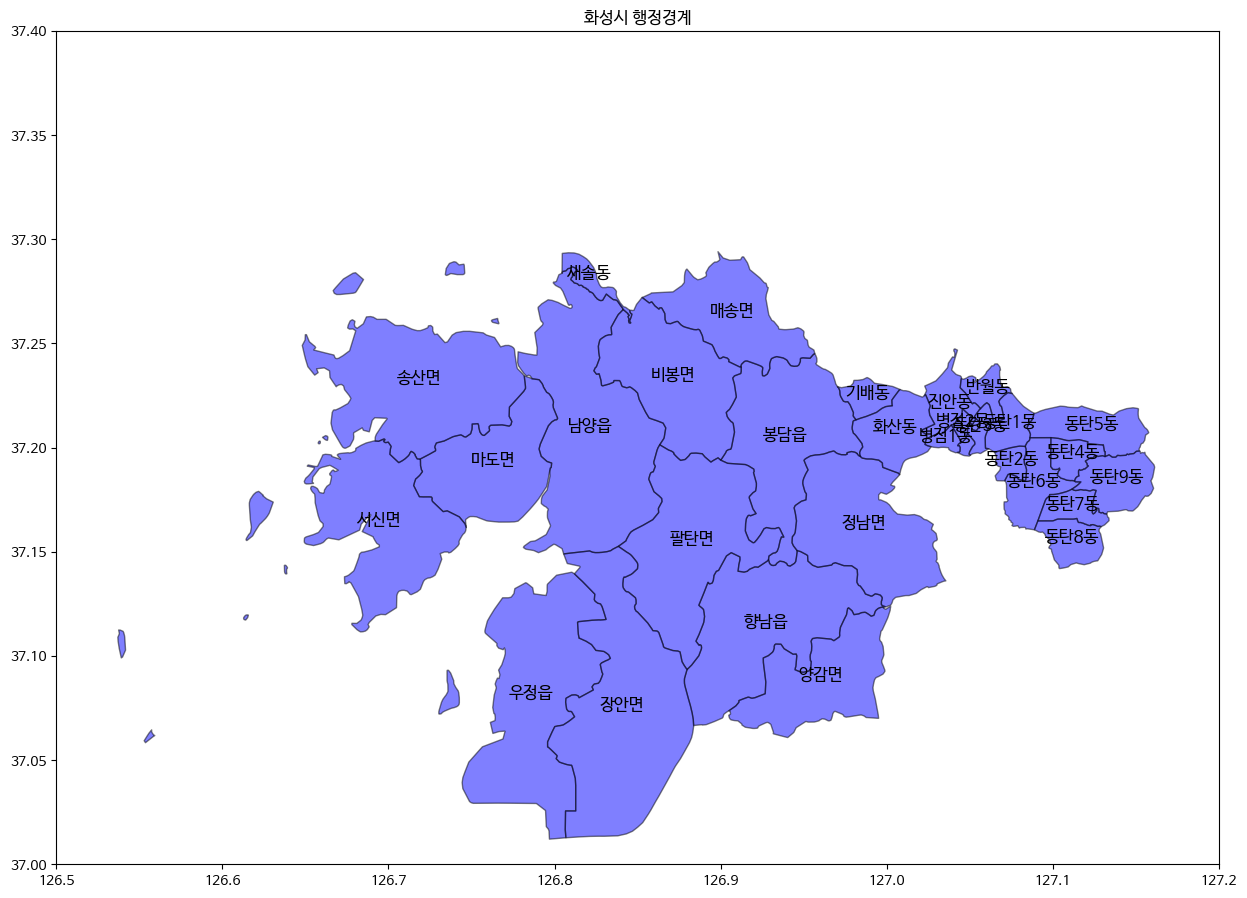

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoDataFrame 읽기
df_boundary = gpd.read_file(file_path_boundary)

# 좌표계를 WGS84 (EPSG:4326)로 변환 (필요할 경우)
if df_boundary.crs != 'EPSG:4326':
    df_boundary = df_boundary.to_crs(epsg=4326)

# 1. '경기도 화성시'와 관련된 데이터만 필터링
df_hwaseong_boundary = df_boundary[df_boundary['adm_nm'].str.contains('화성시')].reset_index(drop=True)

# MultiPolygon 경계면 시각화
fig, ax = plt.subplots(figsize=(15, 15))  # 그림 크기 확대

# 경계면 시각화
df_hwaseong_boundary.plot(
    ax=ax,
    color='blue',  # 채우기 색상
    edgecolor='black',  # 테두리 색상
    linewidth=1,  # 테두리 두께
    alpha=0.5  # 투명도
)

# 행정동 이름에서 '경기도 화성시'를 제외하고 표시
for idx, row in df_hwaseong_boundary.iterrows():
    # 중심점 계산
    centroid = row.geometry.centroid
    # '경기도 화성시'를 제외한 동 이름만 표시
    short_name = row['adm_nm'].replace('경기도 화성시 ', '')  # '경기도 화성시' 제거
    # 중심점에 행정동 이름 표시
    ax.annotate(text=short_name, xy=(centroid.x, centroid.y),
                horizontalalignment='center', fontsize=12, color='black')

# x축(y축)을 위도와 경도 범위로 설정 (경기도 화성시 범위)
ax.set_xlim(126.5, 127.2)  # 경도 범위 설정
ax.set_ylim(37.0, 37.4)    # 위도 범위 설정

# 제목 설정
ax.set_title('화성시 행정경계')

# 지도 표시
plt.show()


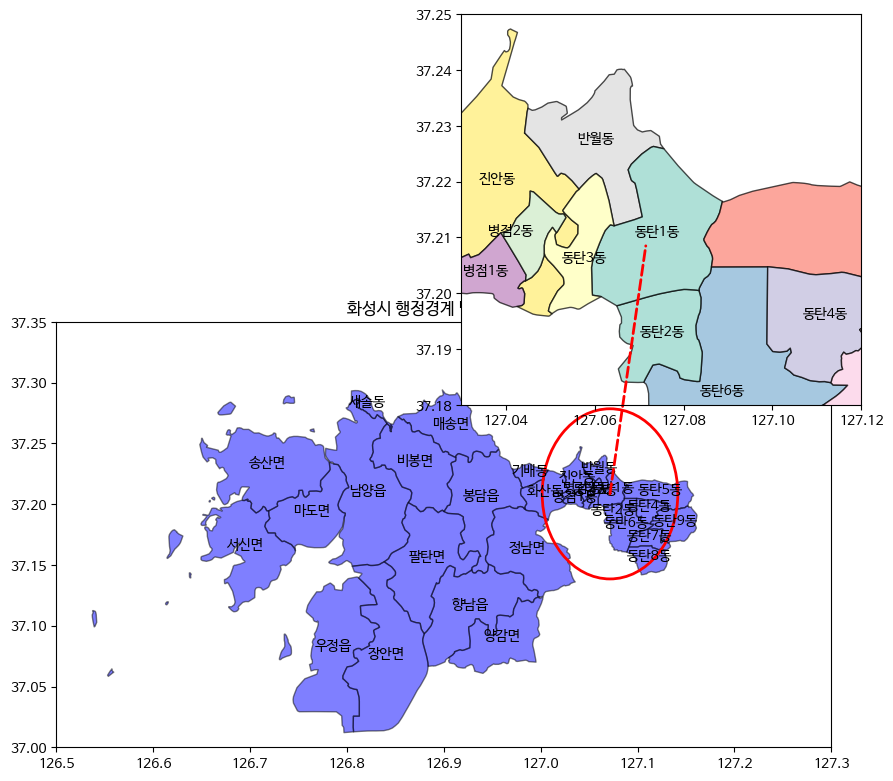

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch

# 1. 메인 지도 시각화
fig, ax1 = plt.subplots(figsize=(10, 10))  # 메인 지도

# 메인 지도 그리기
df_hwaseong_boundary.plot(
    ax=ax1,
    color='blue',
    edgecolor='black',
    linewidth=1,
    alpha=0.5
)

# 메인 지도에 모든 행정동 이름 표시
for idx, row in df_hwaseong_boundary.iterrows():
    centroid = row.geometry.centroid
    short_name = row['adm_nm'].replace('경기도 화성시 ', '')
    ax1.annotate(text=short_name, xy=(centroid.x, centroid.y),
                 horizontalalignment='center', fontsize=10, color='black')

# 동탄4동 중심 좌표에 원을 그려서 강조 (원 크기 유지)
circle = Circle((127.0715, 37.2085), 0.07, color='red', fill=False, linewidth=2)  # 동탄4동 중심점 좌표
ax1.add_patch(circle)

# 메인 지도 제목 설정
ax1.set_title('화성시 행정경계 및 확대 지도')

# 메인 지도 축 범위 조정
ax1.set_xlim(126.5, 127.3)
ax1.set_ylim(37.0, 37.35)

# 2. 확대된 부분을 추가로 표시하기 위해 작은 축을 삽입
ax2 = fig.add_axes([0.53, 0.62, 0.4, 0.4])  # 메인 지도 위에 작은 축을 추가 (위치: [왼쪽, 아래쪽, 너비, 높이])

# 동탄1동 중심 좌표 기준으로 더 넓은 확대 범위 설정
zoom_area = df_hwaseong_boundary.cx[127.03:127.12, 36.88:37.23]  # 확대 범위 살짝 넓히기
zoom_area.plot(
    ax=ax2,
    column='adm_nm',  # 색상 구분을 위해 'adm_nm'을 기준으로 컬럼 설정
    cmap='Set3',  # 다양한 색상으로 구분
    edgecolor='black',
    linewidth=1,
    alpha=0.7  # 투명도 조정
)

# 확대된 부분의 행정동 이름 표시
for idx, row in zoom_area.iterrows():
       centroid = row.geometry.centroid
       short_name = row['adm_nm'].replace('경기도 화성시 ', '')
       if short_name == '병점2동':
           xytext = (centroid.x - 0.005, centroid.y - 0.0001)  # 병점2동 텍스트 위치 조정 (왼쪽 아래로 이동)
       elif short_name == '동탄3동':
           xytext = (centroid.x + 0.001, centroid.y - 0.003)  # 동탄3동 텍스트 위치 조정 (오른쪽 위로 이동)
       else:
           xytext = (centroid.x + 0, centroid.y + 0)  # 나머지 텍스트는 기존 위치 유지
       ax2.annotate(text=short_name,
                    xy=(centroid.x, centroid.y),
                    xytext=xytext,
                    ha='center',
                    fontsize=10,
                    color='black')

# 확대 지도 축 범위 조정 (동탄1동 중심으로 맞춤, 범위 확대)
ax2.set_xlim(127.03, 127.12)
ax2.set_ylim(37.18, 37.25)

# 메인 지도와 확대된 영역을 연결하는 선 추가 (ConnectionPatch)
con = ConnectionPatch(
    xyA=(127.0715, 37.2085), xyB=(127.0715, 37.2085),  # 원과 확대 중심을 연결
    coordsA="data", coordsB="data",
    axesA=ax1, axesB=ax2,
    color="red", linewidth=2, linestyle="--"
)
ax2.add_patch(con)

# 지도 표시
plt.show()



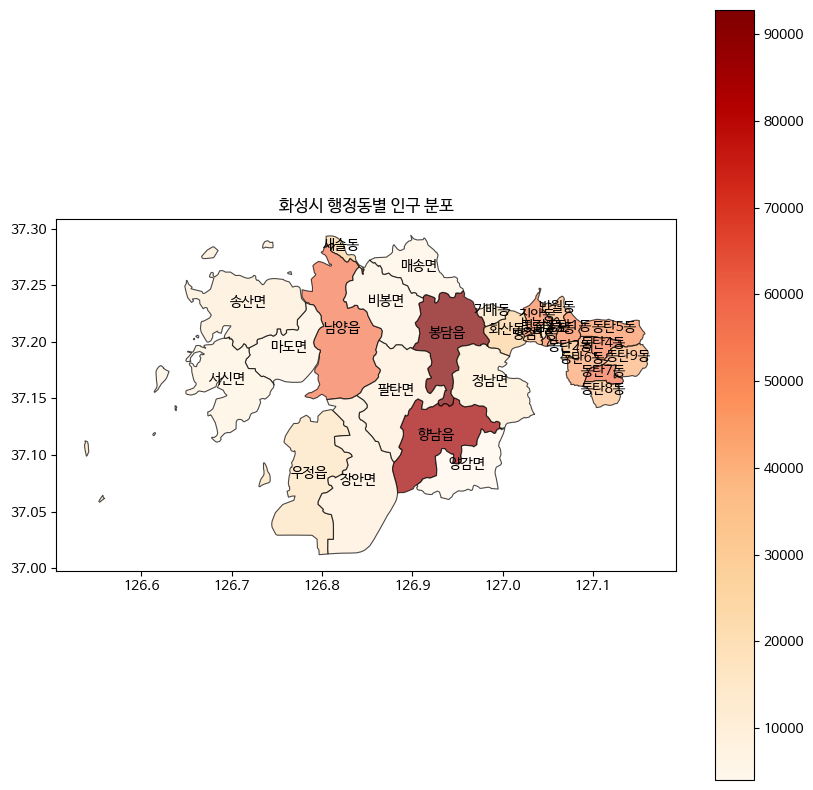

,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,geometry,행정구역,인구수
0,경기도 화성시 봉담읍,4159025300,41590,41,경기도,화성시,31240120,"MULTIPOLYGON (((126.97039 37.2292, 126.97091 3...",경기도 화성시 봉담읍,92823.0
2,경기도 화성시 향남읍,4159025900,41590,41,경기도,화성시,31240140,"MULTIPOLYGON (((126.99914 37.12364, 126.9981 3...",경기도 화성시 향남읍,85647.0
26,경기도 화성시 동탄7동,4159061000,41590,41,경기도,화성시,31240691,"MULTIPOLYGON (((127.11151 37.18002, 127.11273 ...",경기도 화성시 동탄7동,56758.0


In [9]:
df_merged = df_hwaseong_boundary.merge(df_pop, left_on='adm_nm', right_on='행정구역', how='left')

# 인구 수에 따른 색상맵 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 지도에 모든 행정동 이름 표시
for idx, row in df_merged.iterrows():
    centroid = row.geometry.centroid
    short_name = row['adm_nm'].replace('경기도 화성시 ', '')
    ax.annotate(text=short_name, xy=(centroid.x, centroid.y),
                 horizontalalignment='center', fontsize=10, color='black')

# 경계 데이터 시각화 (인구수에 따라 색상 다르게 설정)
df_merged.plot(
    column='인구수',  # 인구수를 기준으로 색상 구분
    ax=ax,
    cmap='OrRd',  # 색상맵 (빨간색 계열로 설정)
    legend=True,  # 범례 추가
    edgecolor='black',  # 경계선 색상
    linewidth=0.8,  # 경계선 두께
    alpha=0.7  # 투명도
)

# 제목 설정
ax.set_title('화성시 행정동별 인구 분포')

# 시각화 출력
plt.show()

df_merged.sort_values(by='인구수',ascending=False)[:3]
# 봉답음, 향남읍, 동탄7동이 인구수가 가장 많음.
# 봉담읍은 수원과의 교통이 편리하며, 신도시개발계획 확장으로 많은 아파트들이 건설되어 있고, 인구소멸지수가 우리나라에서 가장 작은 읍에 속함. 더불어 외국인 인구도 많다.
# 향남읍은 신도시개발계획으로 아파트들이 많고, 외국인 인구비율이 가장 높다.

In [10]:
#히트맵으로 시각화해서 인구보기.
import folium
from folium.plugins import HeatMap

# Folium 지도 생성
m = folium.Map(location=[37.1994932, 126.8311887], zoom_start=11)

# 인구 데이터에서 위도와 경도를 가져와 히트맵 생성
heat_data = [[row.geometry.centroid.y, row.geometry.centroid.x, row['인구수']] for idx, row in df_merged.iterrows()]

# 히트맵을 지도에 추가
HeatMap(heat_data).add_to(m)

# 지도 저장
m.save("heatmap_hwaseong.html")

# 결과 출력
m


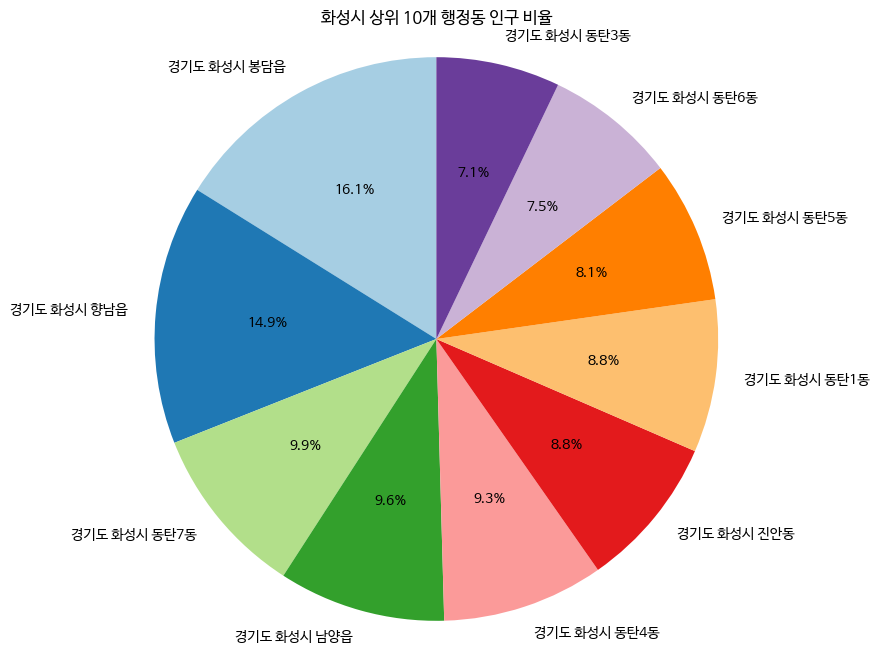

In [11]:
# 인구 수가 많은 상위 10개 행정동 선택
df_sorted = df_pop.sort_values(by='인구수', ascending=False).head(10)

# 파이 차트 시각화
plt.figure(figsize=(8, 8))
plt.pie(df_sorted['인구수'], labels=df_sorted['행정구역'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('화성시 상위 10개 행정동 인구 비율')
plt.axis('equal')  # 원이 찌그러지지 않도록 설정
plt.show()

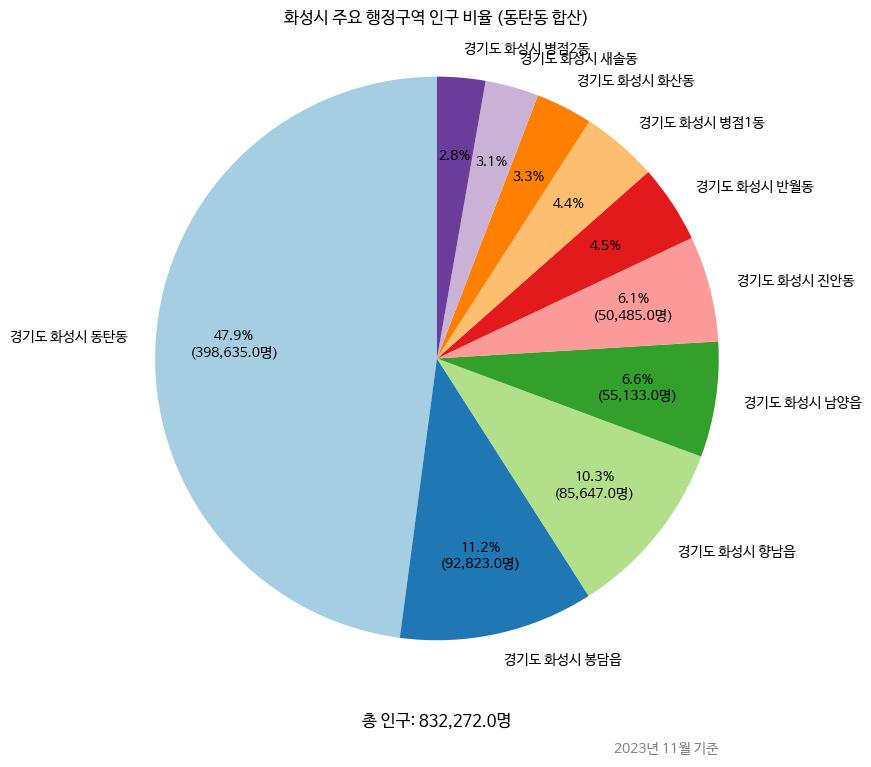

In [12]:
# Adjusted code to improve spacing and selectively show population counts only for top 5 regions

import matplotlib.pyplot as plt

# Temporary copy of df_pop with "경기도 화성시" prefix included in replacement
df_merged_temp = df_pop.copy()

# Replace specific 동탄1~9동 with '동탄동', including "경기도 화성시" prefix
df_merged_temp['행정구역'] = df_merged_temp['행정구역'].replace({
    '경기도 화성시 동탄1동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄2동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄3동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄4동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄5동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄6동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄7동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄8동': '경기도 화성시 동탄동',
    '경기도 화성시 동탄9동': '경기도 화성시 동탄동'
})

# Group by '행정구역' and sum up the population counts for each unique region
df_grouped = df_merged_temp.groupby('행정구역', as_index=False)['인구수'].sum()

# Sort by population and select the top 10 regions
df_sorted = df_grouped.sort_values(by='인구수', ascending=False).head(10)

# Pie chart visualization with selective annotations
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    df_sorted['인구수'], labels=df_sorted['행정구역'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors
)

# Add custom annotations: show population count for top 5 regions only
for i, aut in enumerate(autotexts):
    percent_text = aut.get_text()
    if i < 5:  # Top 5 regions show both percentage and population count
        count_text = f"{df_sorted['인구수'].iloc[i]:,}명"
        aut.set_text(f"{percent_text}\n({count_text})")  # Line break for readability
    else:  # Remaining regions show only percentage
        aut.set_text(percent_text)
    aut.set_position((aut.get_position()[0] * 1.2, aut.get_position()[1] * 1.2))  # Move text slightly outward

# Title and total population count with additional spacing
total_population = df_sorted['인구수'].sum()
plt.title('화성시 주요 행정구역 인구 비율 (동탄동 합산)', pad=20)  # Increase title padding

plt.text(0, -1.3, f"총 인구: {total_population:,}명", ha='center', fontsize=12)

# Reference date
reference_date = "2023년 11월 기준"
plt.text(1, -1.4, reference_date, ha='right', fontsize=10, color="gray")

plt.axis('equal')  # Ensures the pie chart is circular
plt.show()


In [13]:
# 면적 데이터셋 생성
area_data = {
    '행정구역': ['봉담읍', '우정읍', '향남읍', '남양읍', '매송면', '비봉면', '마도면', '송산면', '서신면', '팔탄면', '장안면', '양감면',
             '정남면', '새솔동', '진안동', '병점1. 2동', '반월동', '기배동', '화산동', '동탄1동', '동탄2동', '동탄3동',
             '동탄4동', '동탄5동', '동탄6동', '동탄7동', '동탄8동', '동탄9동'],
    '면적': [42_726_086.50, 61_674_509.70, 50_012_902.60, 67_406_090.60, 27_277_269.50, 38_542_967.10, 32_918_128.90,
            58_366_589.70, 43_492_560.90, 50_970_334.00, 67_663_567.20, 31_057_470.70, 40_678_659.10, 2_976_159.20,
            6_199_591.40, 2_519_368.20, 3_966_588.50, 4_253_652.20, 11_614_640.90, 9_030_000.00, 24_010_000.00,
            9_959_807.10, 4_236_978.70, 11_410_447.30, 9_489_892.80, 4_726_993.80, 6_534_144.30, 9_966_101.60]  # 면적 데이터
}

# DataFrame으로 변환
df_area = pd.DataFrame(area_data)


In [14]:
pop_districts = df_pop['행정구역'].unique()

# 2. df_area에서 행정구역 목록 추출
area_districts = df_area['행정구역'].unique()

# 3. df_pop에만 있는 행정구역 찾기
pop_only = set(pop_districts) - set(area_districts)

# 4. df_area에만 있는 행정구역 찾기
area_only = set(area_districts) - set(pop_districts)

# 5. 결과 출력
print(f"df_pop에만 있는 행정구역: {pop_only}")
print(f"df_area에만 있는 행정구역: {area_only}")

df_pop에만 있는 행정구역: {'경기도 화성시 동탄7동', '경기도 화성시 향남읍', '경기도 화성시 진안동', '경기도 화성시 마도면', '경기도 화성시 남양읍', '경기도 화성시 정남면', '경기도 화성시 서신면', '경기도 화성시 봉담읍', '경기도 화성시 동탄3동', '경기도 화성시 매송면', '경기도 화성시 동탄8동', '경기도 화성시 팔탄면', '경기도 화성시 기배동', '경기도 화성시 병점1동', '경기도 화성시 반월동', '경기도 화성시 우정읍', '경기도 화성시 병점2동', '경기도 화성시 비봉면', '경기도 화성시 화산동', '경기도 화성시 동탄2동', '경기도 화성시 동탄5동', '경기도 화성시 새솔동', '경기도 화성시 동탄9동', '경기도 화성시 송산면', '경기도 화성시 동탄4동', '경기도 화성시 양감면', '경기도 화성시 동탄6동', '경기도 화성시 동탄1동', '경기도 화성시 장안면'}
df_area에만 있는 행정구역: {'반월동', '송산면', '동탄8동', '동탄7동', '팔탄면', '동탄1동', '서신면', '동탄5동', '병점1. 2동', '진안동', '마도면', '장안면', '비봉면', '동탄3동', '동탄2동', '새솔동', '우정읍', '기배동', '정남면', '동탄4동', '봉담읍', '동탄9동', '매송면', '남양읍', '향남읍', '화산동', '양감면', '동탄6동'}


In [15]:
# df_area의 행정구역에 '경기도 화성시 ' 접두사 추가
df_area['행정구역'] = '경기도 화성시 ' + df_area['행정구역']

# 결과 확인
df_area

,행정구역,면적
0,경기도 화성시 봉담읍,42726086.5
1,경기도 화성시 우정읍,61674509.7
2,경기도 화성시 향남읍,50012902.6
3,경기도 화성시 남양읍,67406090.6
4,경기도 화성시 매송면,27277269.5
5,경기도 화성시 비봉면,38542967.1
6,경기도 화성시 마도면,32918128.9
7,경기도 화성시 송산면,58366589.7
8,경기도 화성시 서신면,43492560.9
9,경기도 화성시 팔탄면,50970334.0


In [16]:
# 1. '병점1. 2동' 행을 찾아 면적 나눔
idx = df_area[df_area['행정구역'] == '경기도 화성시 병점1. 2동'].index[0]  # '병점1. 2동' 행의 인덱스 찾기

# 2. 병점1동과 병점2동 면적 설정
byungjeom1_area = 1_450_000  # 병점1동의 면적 (m²)
byungjeom2_area = 1_069_368.2  # 병점2동의 면적 (m²)

# 3. 병점1동과 병점2동으로 나눔
df_area.loc[idx, '행정구역'] = '경기도 화성시 병점1동'  # 기존 병점1. 2동 행을 병점1동으로 업데이트
df_area.loc[idx, '면적'] = byungjeom1_area  # 병점1동의 면적을 명확히 지정

# 4. 병점2동 행 추가
df_area.loc[len(df_area)] = ['경기도 화성시 병점2동', byungjeom2_area]  # 병점2동 행 추가

# 5. 동탄1동, 동탄2동, 동탄3동 면적 업데이트
df_area.loc[df_area['행정구역'] == '경기도 화성시 동탄1동', '면적'] = 5_300_000  # 동탄1동 면적 업데이트
df_area.loc[df_area['행정구역'] == '경기도 화성시 동탄2동', '면적'] = 2_200_000  # 동탄2동 면적 업데이트
df_area.loc[df_area['행정구역'] == '경기도 화성시 동탄3동', '면적'] = 2_459_807.1  # 동탄3동 면적 업데이트

# 결과 확인
print(df_area[df_area['행정구역'].str.contains('병점|동탄')])  # 병점동과 동탄동 관련 행만 출력


            행정구역          면적
15  경기도 화성시 병점1동   1450000.0
19  경기도 화성시 동탄1동   5300000.0
20  경기도 화성시 동탄2동   2200000.0
21  경기도 화성시 동탄3동   2459807.1
22  경기도 화성시 동탄4동   4236978.7
23  경기도 화성시 동탄5동  11410447.3
24  경기도 화성시 동탄6동   9489892.8
25  경기도 화성시 동탄7동   4726993.8
26  경기도 화성시 동탄8동   6534144.3
27  경기도 화성시 동탄9동   9966101.6
28  경기도 화성시 병점2동   1069368.2


# **인구 밀집도 데이터 분석**

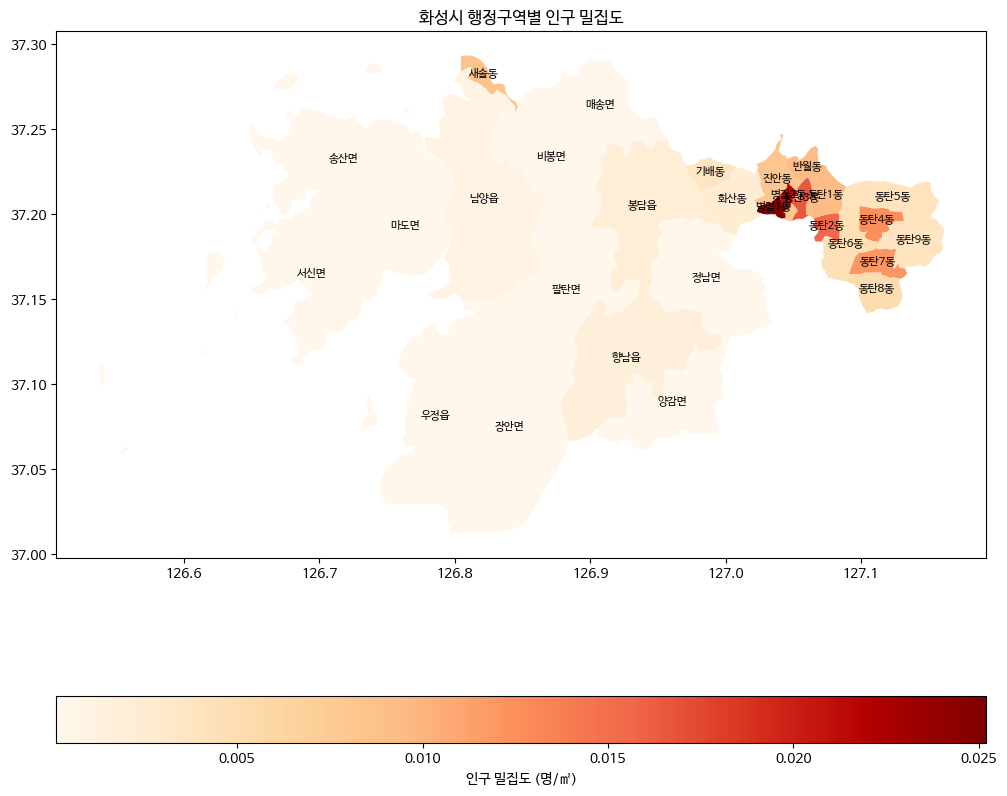

In [17]:
# 1. 면적이 포함된 df_area와 인구가 포함된 df_pop을 병합 (행정구역 기준)
df_merged = pd.merge(df_pop, df_area, on='행정구역')

# 2. 인구 밀집도 계산 (인구 밀집도 = 인구수 / 면적)
df_merged['인구밀집도'] = df_merged['인구수'] / df_merged['면적']

# 3. GeoDataFrame에 병합된 데이터프레임 결합
df_final = df_hwaseong_boundary.merge(df_merged, left_on='adm_nm', right_on='행정구역', how='left')

# 4. 인구 밀집도에 따른 색상을 적용한 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# GeoDataFrame을 인구 밀집도에 따라 시각화 (색상 적용)
df_final.plot(column='인구밀집도', ax=ax, cmap='OrRd', legend=True,
              legend_kwds={'label': "인구 밀집도 (명/㎡)", 'orientation': "horizontal"})

# 행정동 이름에서 '경기도 화성시'를 제외하고 표시
for idx, row in df_final.iterrows():
    centroid = row.geometry.centroid
    short_name = row['adm_nm'].replace('경기도 화성시 ', '')
    ax.annotate(text=short_name, xy=(centroid.x, centroid.y),
                horizontalalignment='center', fontsize=8, color='black')

# 제목 설정
ax.set_title('화성시 행정구역별 인구 밀집도')

# 결과 시각화
plt.show()

C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3280588049.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='행정구역', y='인구밀집도', data=top_5_density, palette='Blues_d')


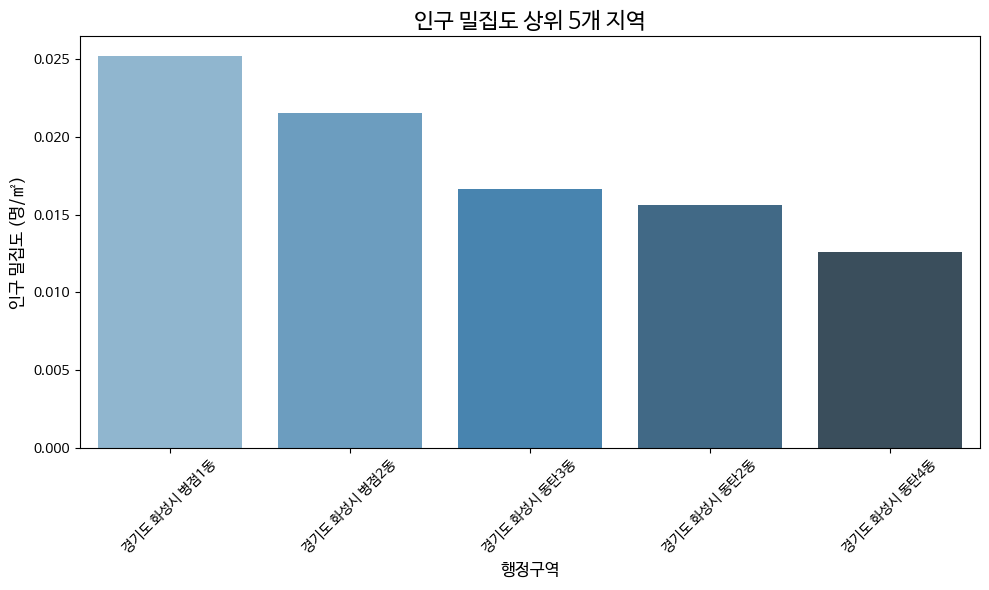

In [18]:
import seaborn as sns
# 인구 밀집도 상위 5개 지역 추출
top_5_density = df_merged.nlargest(5, '인구밀집도')

# 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='행정구역', y='인구밀집도', data=top_5_density, palette='Blues_d')
plt.title('인구 밀집도 상위 5개 지역', fontsize=16)
plt.xlabel('행정구역', fontsize=12)
plt.ylabel('인구 밀집도 (명/㎡)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **유동인구 데이터 분석**

In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 유동인구 데이터 불러오기
file_path_floating_population = r'G:\내 드라이브\화성 데이터 공모전\데이터파일\화성시 동별 유동인구.csv' #공공데이터포탈
df_flowpop_original = pd.read_csv(file_path_floating_population,index_col=0)
df_flowpop_copy = df_flowpop_original.copy()
df_flowpop_copy




,ADMI_CD,CTY_NM,ADMI_NM,TIME_CD,FORN_GB,M_10_CNT,M_15_CNT,M_20_CNT,M_25_CNT,M_30_CNT,...,F_30_CNT,F_35_CNT,F_40_CNT,F_45_CNT,F_50_CNT,F_55_CNT,F_60_CNT,F_65_CNT,F_70_CNT,ETL_YMD
0,41590330,화성시,마도면,12,내국인,35.83,12.52,12.86,30.31,42.46,...,29.03,47.25,38.09,54.24,75.66,126.65,121.39,88.08,58.63,20231202
1,41590262,화성시,남양읍,8,내국인,312.24,274.15,253.00,778.25,1043.42,...,612.11,499.34,572.93,430.74,590.08,618.22,603.09,389.29,217.81,20231222
2,41590256,화성시,우정읍,23,외국인,0.00,2.09,54.27,93.92,123.15,...,33.40,27.13,29.22,25.05,18.78,22.96,14.61,4.17,8.35,20231209
3,41590320,화성시,비봉면,12,내국인,25.85,22.12,48.49,78.51,115.00,...,81.42,40.07,78.80,89.15,71.20,88.22,127.05,90.80,42.54,20231216
4,41590588,화성시,동탄4동,1,내국인,186.88,194.71,101.51,98.51,104.25,...,153.51,213.08,371.47,379.30,262.68,90.55,92.10,46.52,14.57,20231214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381865,41590360,화성시,팔탄면,10,내국인,52.75,63.70,26.27,69.11,78.88,...,62.59,108.17,109.46,130.65,302.24,313.53,241.95,220.58,119.15,20240824
381866,41590370,화성시,장안면,14,외국인,0.00,23.44,125.74,240.83,319.68,...,66.07,53.28,55.41,42.62,51.15,19.18,14.92,8.52,6.39,20240828
381867,41590530,화성시,병점1동,18,외국인,0.00,1.70,8.52,8.52,3.41,...,22.15,10.22,5.11,8.52,13.63,6.82,8.52,3.41,1.70,20240819
381868,41590370,화성시,장안면,20,내국인,28.74,10.89,17.48,23.60,28.81,...,18.32,20.25,27.16,30.68,50.21,53.49,64.33,67.91,57.50,20240813


In [20]:
# 컬럼명 변경 for easier use
df_flowpop_copy['TOTAL_POPULATION'] = df_flowpop_copy[[
    'M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT',
    'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT',
    'F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT',
    'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT',
    'F_70_CNT'
]].sum(axis=1)
df_flowpop_copy.rename(columns={'ADMI_NM': '행정구역', 'ETL_YMD': '날짜', 'CTY_NM': '도시명', 'TOTAL_POPULATION': '총유동인구수'}, inplace=True)
# 필요 없는 컬럼 제거
df_flowpop_copy.drop(columns=['도시명'], inplace=True)

In [21]:
# 유동인구 데이터를 처리하여 평일과 주말로 나누기
# 날짜 컬럼을 datetime 타입으로 변환
df_flowpop_copy['날짜'] = pd.to_datetime(df_flowpop_copy['날짜'], format='%Y%m%d')
df_flowpop_copy['요일'] = df_flowpop_copy['날짜'].dt.dayofweek
# 날짜 컬럼을 datetime 타입으로 변환
df_flowpop_copy['날짜'] = pd.to_datetime(df_flowpop_copy['날짜'], format='%Y%m%d')
df_flowpop_copy['요일'] = df_flowpop_copy['날짜'].dt.dayofweek

# 평일(월~금: 0~4)과 주말(토, 일: 5, 6)로 구분하는 컬럼 생성
df_flowpop_copy['평일'] = df_flowpop_copy['요일'] < 5
df_flowpop_copy['주말'] = df_flowpop_copy['요일'] >= 5

# 행정구역 이름에 '경기도 화성시' 접두사 추가
df_flowpop_copy['행정구역'] = '경기도 화성시 ' + df_flowpop_copy['행정구역']

In [22]:
# 평일과 주말의 유동인구 각각 계산
df_weekday = df_flowpop_copy[df_flowpop_copy['평일']].groupby('행정구역')['총유동인구수'].mean().reset_index()
df_weekend = df_flowpop_copy[df_flowpop_copy['주말']].groupby('행정구역')['총유동인구수'].mean().reset_index()
df_weekend = df_flowpop_copy[df_flowpop_copy['주말']].groupby('행정구역')['총유동인구수'].mean().reset_index()
df_weekday.rename(columns={'총유동인구수': '평일평균유동인구수'}, inplace=True)
df_weekend.rename(columns={'총유동인구수': '주말평균유동인구수'}, inplace=True)


In [23]:
# 면적이 포함된 df_area와 인구가 포함된 df_pop을 병합 (행정구역 기준)
df_merged = pd.merge(df_pop, df_area, on='행정구역')

# 인구 밀집도 계산 (인구 밀집도 = 인구수 / 면적)
df_merged['인구밀집도'] = df_merged['인구수'] / df_merged['면적']

# df_hwaseong_boundary의 adm_nm 컬럼명 변경
df_hwaseong_boundary.rename(columns={'adm_nm': '행정구역'}, inplace=True)

# GeoDataFrame에 병합된 데이터프레임 결합
df_final = df_hwaseong_boundary.join(df_merged.set_index('행정구역'), on='행정구역', how='left').drop(columns=['adm_cd2', 'sgg', 'sido', 'sidonm', 'sggnm', 'adm_cd'])

# 유동 인구 데이터 추가 (평일과 주말 평균 유동인구로 병합)
df_final = df_final.join(df_weekday.set_index('행정구역'), on='행정구역', how='left')
df_final = df_final.join(df_weekend.set_index('행정구역'), on='행정구역', how='left')


In [24]:
# 데이터 정리 단계 - 필요한 컬럼 선택 및 결측값 처리
# 필요한 컬럼만 선택 (인구수, 인구 밀집도, 평일평균유동인구수, 주말평균유동인구수 등)
df_final = df_final[['행정구역', 'geometry', '인구수', '면적', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수']]

In [25]:
df_final.to_csv("행정동별 경계, 인구, 면적, 인구밀집도, 유동인구.csv")

In [26]:
df_final

,행정구역,geometry,인구수,면적,인구밀집도,평일평균유동인구수,주말평균유동인구수
0,경기도 화성시 봉담읍,"MULTIPOLYGON (((126.97039 37.2292, 126.97091 3...",92823.0,42726086.5,0.002173,10723.788862,10745.788676
1,경기도 화성시 우정읍,"MULTIPOLYGON (((126.55815 37.06117, 126.55367 ...",17439.0,61674509.7,0.000283,3201.728619,2440.049164
2,경기도 화성시 향남읍,"MULTIPOLYGON (((126.99914 37.12364, 126.9981 3...",85647.0,50012902.6,0.001712,10253.758784,9875.153436
3,경기도 화성시 남양읍,"MULTIPOLYGON (((126.84097 37.26592, 126.83923 ...",55133.0,67406090.6,0.000818,8418.973051,7289.849734
4,경기도 화성시 매송면,"MULTIPOLYGON (((126.92737 37.2788, 126.92759 3...",6742.0,27277269.5,0.000247,1054.646442,1150.054061
5,경기도 화성시 비봉면,"MULTIPOLYGON (((126.91237 37.2386, 126.91239 3...",7009.0,38542967.1,0.000182,1187.964770,932.576129
6,경기도 화성시 마도면,"MULTIPOLYGON (((126.78641 37.23298, 126.78706 ...",6854.0,32918128.9,0.000208,1317.211665,881.812260
7,경기도 화성시 송산면,"MULTIPOLYGON (((126.65837 37.20181, 126.65827 ...",10830.0,58366589.7,0.000186,1611.813230,1503.683528
8,경기도 화성시 서신면,"MULTIPOLYGON (((126.61494 37.11967, 126.61497 ...",7114.0,43492560.9,0.000164,1259.340347,1926.353434
9,경기도 화성시 팔탄면,"MULTIPOLYGON (((126.8999 37.19404, 126.90113 3...",9894.0,50970334.0,0.000194,2729.913071,2050.945277


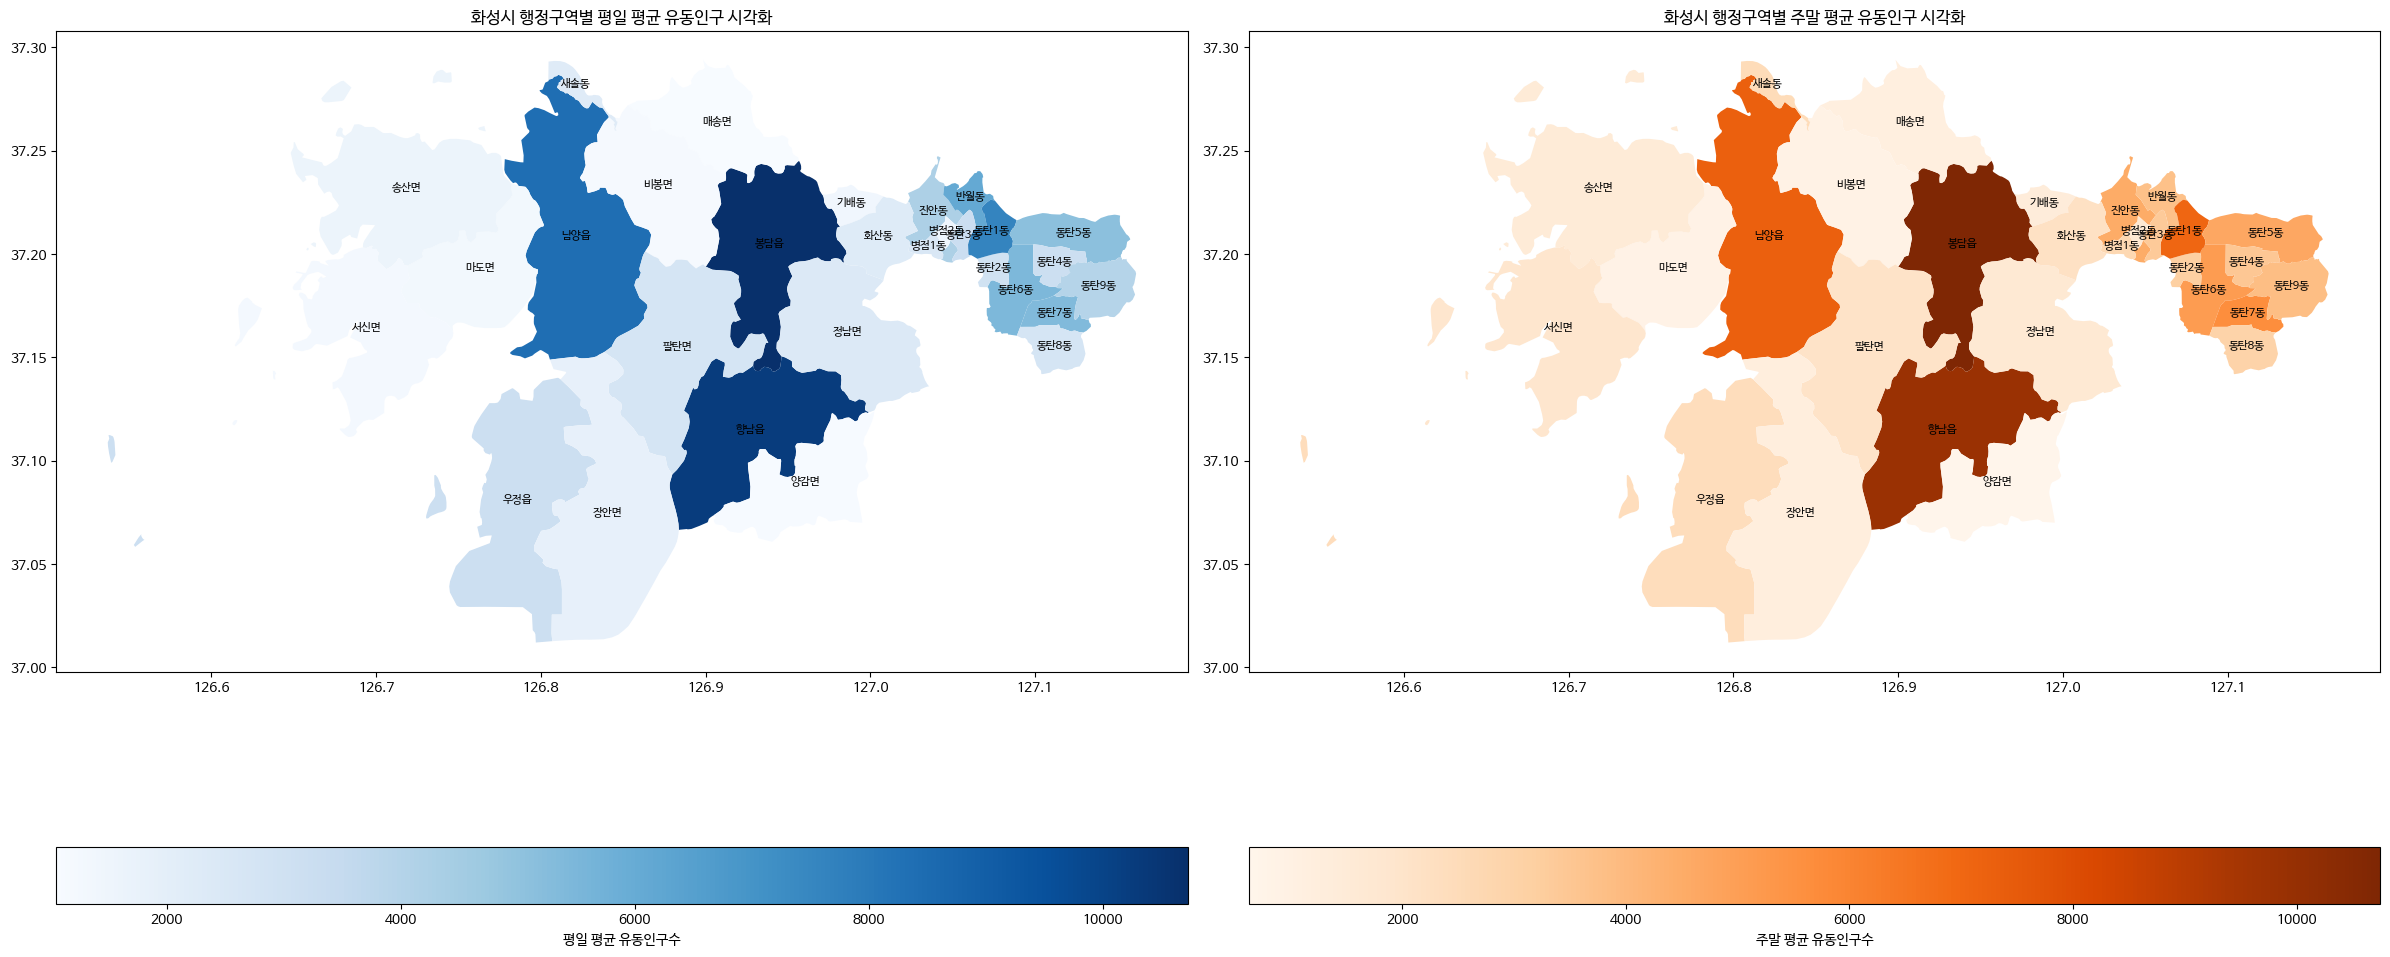

In [27]:
# 평일과 주말 평균 유동인구 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

# 평일 평균 유동인구 시각화
df_final.plot(column='평일평균유동인구수', ax=ax1, cmap='Blues', legend=True,
              legend_kwds={'label': "평일 평균 유동인구수", 'orientation': "horizontal"})
ax1.set_title('화성시 행정구역별 평일 평균 유동인구 시각화')

# 주말 평균 유동인구 시각화
df_final.plot(column='주말평균유동인구수', ax=ax2, cmap='Oranges', legend=True,
              legend_kwds={'label': "주말 평균 유동인구수", 'orientation': "horizontal"})
ax2.set_title('화성시 행정구역별 주말 평균 유동인구 시각화')

# 행정동 이름에서 '경기도 화성시'를 제외하고 표시
for ax in [ax1, ax2]:
    for idx, row in df_final.iterrows():
        centroid = row.geometry.centroid
        short_name = row['행정구역'].replace('경기도 화성시 ', '')
        ax.annotate(text=short_name, xy=(centroid.x, centroid.y),
                    horizontalalignment='center', fontsize=8, color='black')

# 결과 시각화
plt.tight_layout()
plt.show()


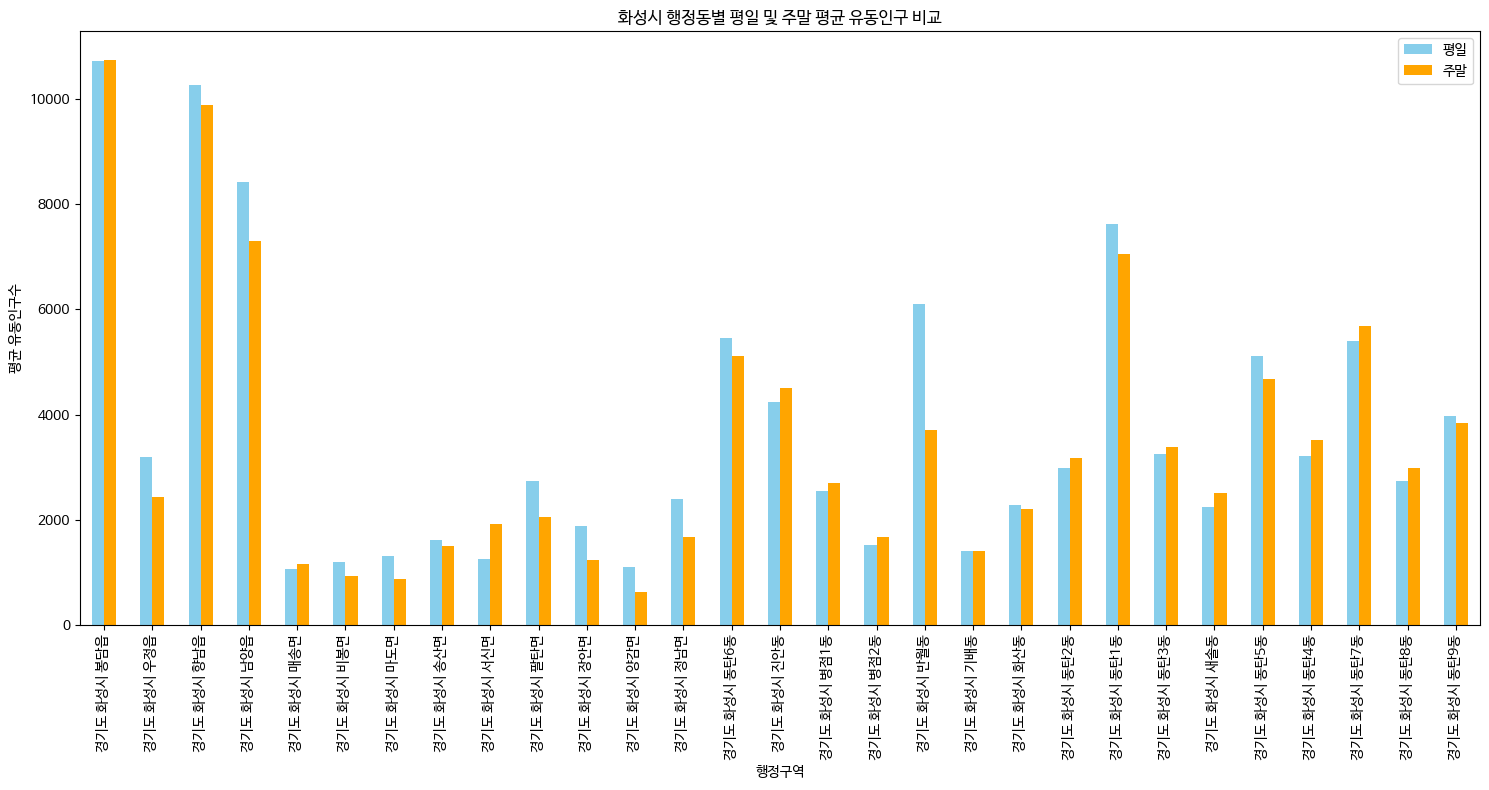

In [28]:
# 막대그래프를 통한 행정동별 평일/주말 평균 유동인구 비교
plt.figure(figsize=(15, 8))
df_grouped = df_final[['행정구역', '평일평균유동인구수', '주말평균유동인구수']]
df_grouped.set_index('행정구역')[['평일평균유동인구수', '주말평균유동인구수']].plot(kind='bar', ax=plt.gca(), color=['skyblue', 'orange'])
plt.title('화성시 행정동별 평일 및 주말 평균 유동인구 비교')
plt.xlabel('행정구역')
plt.ylabel('평균 유동인구수')
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(["평일", "주말"])
plt.show()

# **도로 데이터 분석**

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Shapefile 경로 설정
shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"

# Geopandas로 화성시 도로 데이터 읽기
gdf = gpd.read_file(shapefile_path,encoding='euc-kr')

# 데이터프레임의 기본 정보 출력 (컬럼명 등 확인)
print(gdf.head())
print(gdf.columns)

<>:5: SyntaxWarning: invalid escape sequence '\Z'
<>:5: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\1254251114.py:5: SyntaxWarning: invalid escape sequence '\Z'
  shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


                 PRESENT_SN LCLAS_CL MLSFC_CL SCLAS_CL ATRB_SE  \
0  44790UQ151PS202002170001   UQS120     None     None  UQS120   
1  44790UQ151PS198912070518   UQS117     None     None  UQS117   
2  44790UQ151PS201808200065   UQS119     None     None  UQS119   
3  44790UQ151PS201808200076   UQS122     None     None  UQS122   
4  44790UQ151PS199903270383   UQS121     None     None  UQS121   

               WTNNC_SN               NTFC_SN DGM_NM   DGM_AR  DGM_LT  \
0  44790URZ202002170001  44790NTC202002170001   소로1류   2866.0   516.0   
1  44790URZ201902250028  44790NTC201902250005   중로1류  42515.0  3900.0   
2  44790URZ201911270024  44790NTC201911270017   중로3류   1041.0   211.0   
3  44790URZ201911150023  44790NTC201911150016   소로3류   1185.0   411.0   
4  44790URZ201911140020  44790NTC201911140013   소로2류   1012.0   290.0   

  SIGNGU_SE GRAD_SE ROAD_TY ROAD_NO ROAD_ROLE DRAWING_NO EXCUT_SE CREATE_DAT  \
0     44790      소로       1       1   PMI0004       None  EMA0002       None   
1   

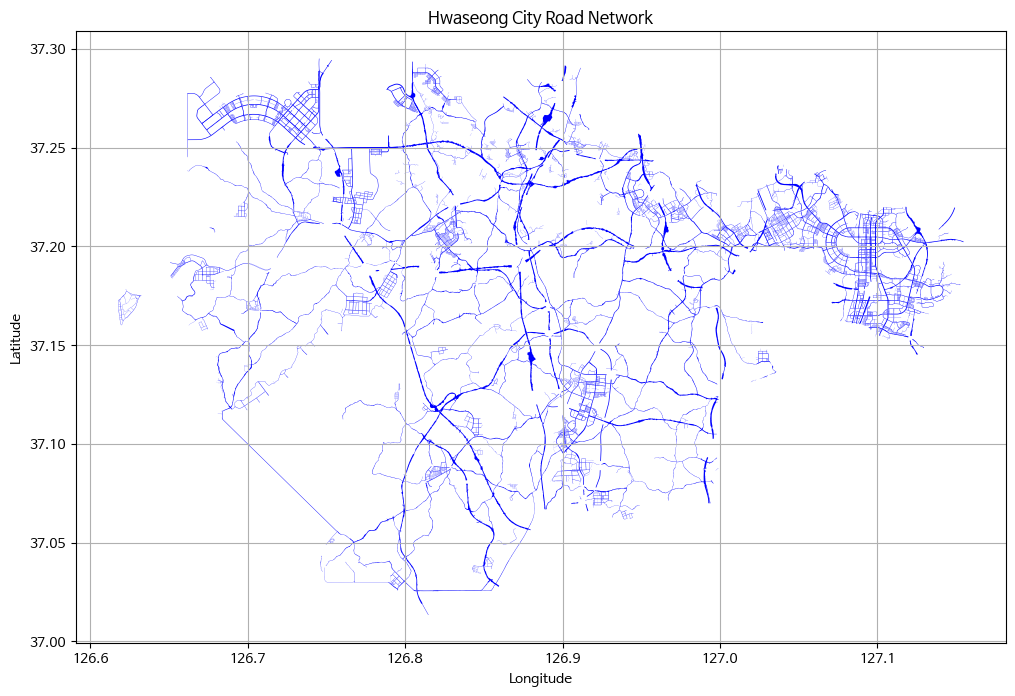

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 화성시 (행정구역 코드: 41590) 도로 데이터 필터링
hwaseong_gdf = gdf[gdf['SIGNGU_SE'] == '41590']

# 도로 데이터만 필터링 (가정: 도로 관련 컬럼 이름이 'DGM_NM' 또는 유사한 경우, 예를 들어 '소로', '중로', '대로' 등이 포함된 경우)
road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('소로|중로|대로|광로', na=False)]  # na=False로 NaN 값 처리

# 위도/경도 좌표계로 변환 (EPSG:4326)
road_gdf = road_gdf.to_crs(epsg=4326)

# 도로 데이터 시각화 (필터링 후 실행)
plt.figure(figsize=(12, 12))
ax = plt.gca()
road_gdf.plot(ax=ax, color='blue', linewidth=0.5)  # EPSG:4326 좌표계로 변환하여 시각화

plt.title("Hwaseong City Road Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


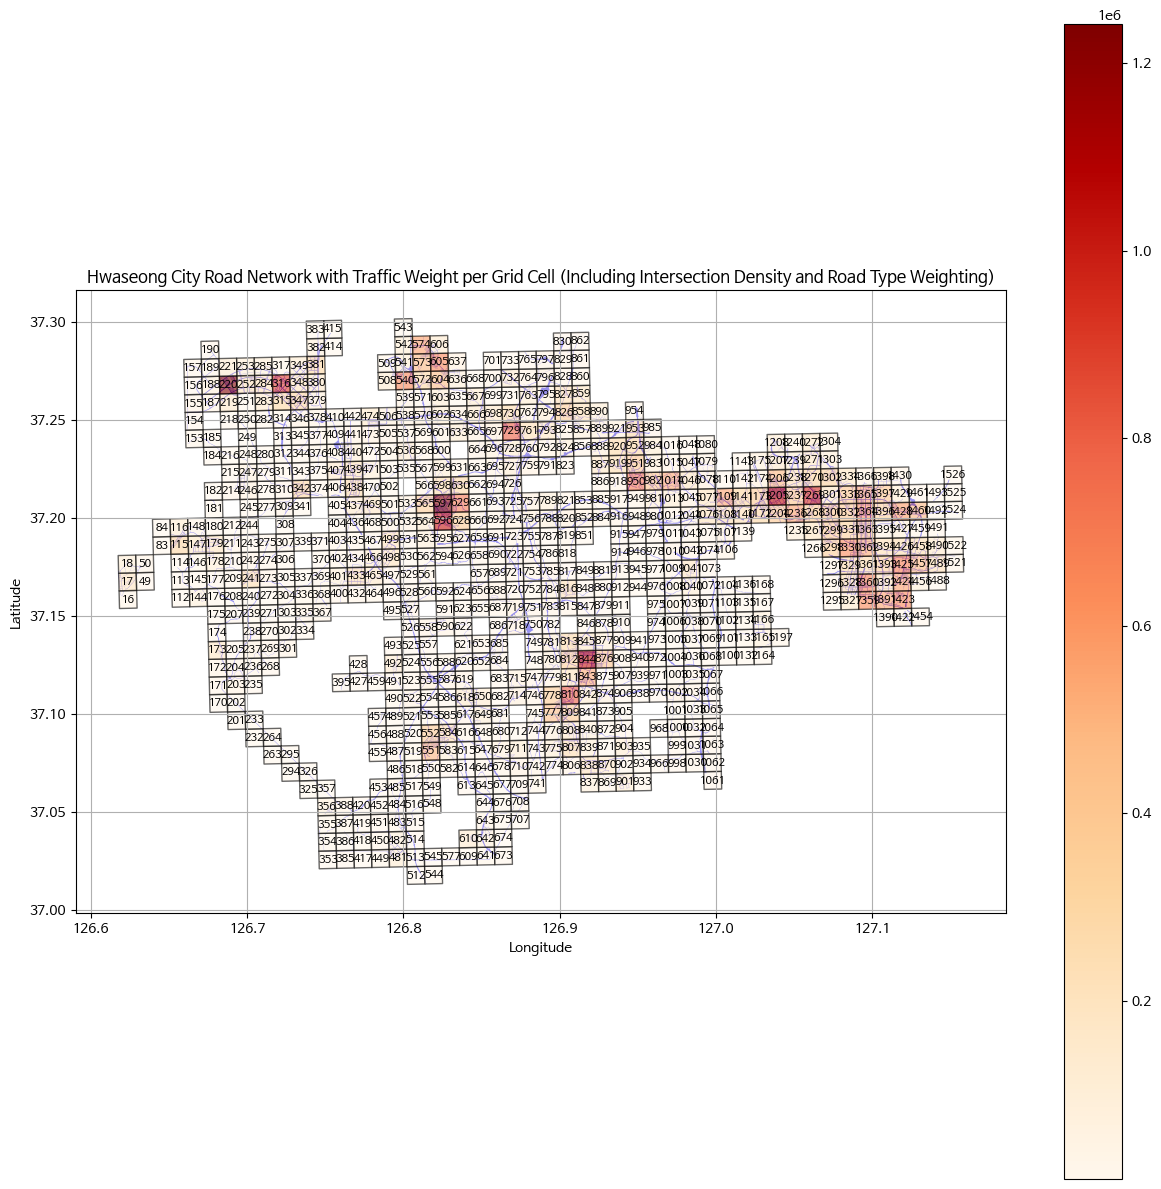

In [31]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# (이전 코드와 동일한 데이터 처리 및 가중치 설정 부분 생략)

# 도로 유형별 가중치 설정 (수정된 가중치)
road_rank_weights = {
    '광로': 1.0,    # 광로 - 매우 높은 교통량
    '대로': 0.8,    # 대로 - 높은 교통량
    '중로': 0.6,    # 중로 - 중간 교통량
    '소로': 0.4     # 소로 - 낮은 교통량
}

# 도로 랭크를 기반으로 교통량 가중치 할당
road_gdf.loc[:, '교통량_가중치'] = road_gdf['DGM_NM'].map(lambda name: next((weight for key, weight in road_rank_weights.items() if key in name), 0))

# 좌표계를 UTM으로 변환하여 정확한 면적 계산 (EPSG:32652)
road_gdf = road_gdf.to_crs(epsg=32652)
road_gdf['도로_면적'] = road_gdf.geometry.area

# 그리드 데이터 생성 (1km x 1km 그리드 생성 예시)
xmin, ymin, xmax, ymax = road_gdf.total_bounds
cell_size = 1000  # 1km
cols = list(np.arange(xmin, xmax, cell_size))
rows = list(np.arange(ymin, ymax, cell_size))
grid_cells = []
for x in cols:
    for y in rows:
        grid_cells.append(Polygon([(x, y), (x + cell_size, y), (x + cell_size, y + cell_size), (x, y + cell_size)]))

# 그리드 GeoDataFrame 생성
grid_gdf = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs='EPSG:32652')
grid_gdf['grid_id'] = range(len(grid_gdf))

# 그리드와 도로 데이터의 교차를 통해 교통량 할당
grid_with_roads = gpd.overlay(grid_gdf, road_gdf, how='intersection')

# 교차 면적을 고려한 가중치 계산
grid_with_roads['교차_면적'] = grid_with_roads.geometry.area

# 도로_면적과 교통량_가중치 컬럼이 존재하는지 확인 후 병합
grid_with_roads = grid_with_roads.merge(road_gdf[['도로_면적', '교통량_가중치']].reset_index(), left_index=True, right_index=True, how='left', suffixes=('', '_road'))

# 가중치 계산
grid_with_roads['가중치_교통량'] = grid_with_roads['교통량_가중치'] * (grid_with_roads['교차_면적'] / grid_with_roads['도로_면적_road'])

# 각 그리드 셀에 대해 교통량 가중치 합계 계산
grid_with_roads['가중치_교통량'] = grid_with_roads.groupby('grid_id')['가중치_교통량'].transform('sum')

# 교차로 밀집도를 추가로 계산하여 반영 (교차로 수를 가중치로 추가)
grid_with_roads['교차로_가중치'] = grid_with_roads['geometry'].apply(lambda geom: len(list(road_gdf.intersects(geom))) * 2.0)  # 교차로 가중치 2.0으로 증가

# 최종 교통량 가중치 계산 (교차로 가중치 반영)
grid_with_roads['최종_가중치_교통량'] = grid_with_roads['가중치_교통량'] + grid_with_roads['교차로_가중치']

# 각 그리드 셀에 대해 최종 교통량 가중치 합계 계산
grid_traffic_weight = grid_with_roads.dissolve(by='grid_id', aggfunc='sum')[['최종_가중치_교통량']]

# Add geometry back to the aggregated traffic data
grid_traffic_weight = grid_traffic_weight.merge(grid_gdf[['grid_id', 'geometry']], on='grid_id', how='left')
grid_traffic_weight = gpd.GeoDataFrame(grid_traffic_weight, geometry='geometry')

# 시각화를 위한 좌표계 변환 (EPSG:4326, 위도/경도)
road_gdf = road_gdf.to_crs(epsg=4326)
grid_traffic_weight = grid_traffic_weight.to_crs(epsg=4326)

# 시각화
plt.figure(figsize=(15, 15))
ax = plt.gca()

# 도로 데이터 시각화
road_gdf.plot(ax=ax, color='blue', linewidth=0.5, label='Road Network')

# 그리드 데이터와 최종 교통량 가중치 시각화
grid_traffic_weight.plot(ax=ax, column='최종_가중치_교통량', cmap='OrRd', legend=True, edgecolor='black', alpha=0.6)

# 각 그리드의 중심에 grid_id를 표시
for idx, row in grid_traffic_weight.iterrows():
    # 그리드의 중심점 계산
    centroid = row['geometry'].centroid
    # 중심점에 grid_id를 텍스트로 표시
    ax.text(centroid.x, centroid.y, str(row['grid_id']), ha='center', va='center', fontsize=8, color='black')

# 그래프 설정
plt.title("Hwaseong City Road Network with Traffic Weight per Grid Cell (Including Intersection Density and Road Type Weighting)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


In [32]:
grid_traffic_weight
# GeoJSON 파일로 저장
grid_traffic_weight.to_file("grid_traffic_weight.geojson", driver="GeoJSON")

<>:8: SyntaxWarning: invalid escape sequence '\Z'
<>:9: SyntaxWarning: invalid escape sequence '\H'
<>:8: SyntaxWarning: invalid escape sequence '\Z'
<>:9: SyntaxWarning: invalid escape sequence '\H'
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3670918623.py:8: SyntaxWarning: invalid escape sequence '\Z'
  shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3670918623.py:9: SyntaxWarning: invalid escape sequence '\H'
  hwaseong_boundary_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson"
c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3670918623.py:78: UserW

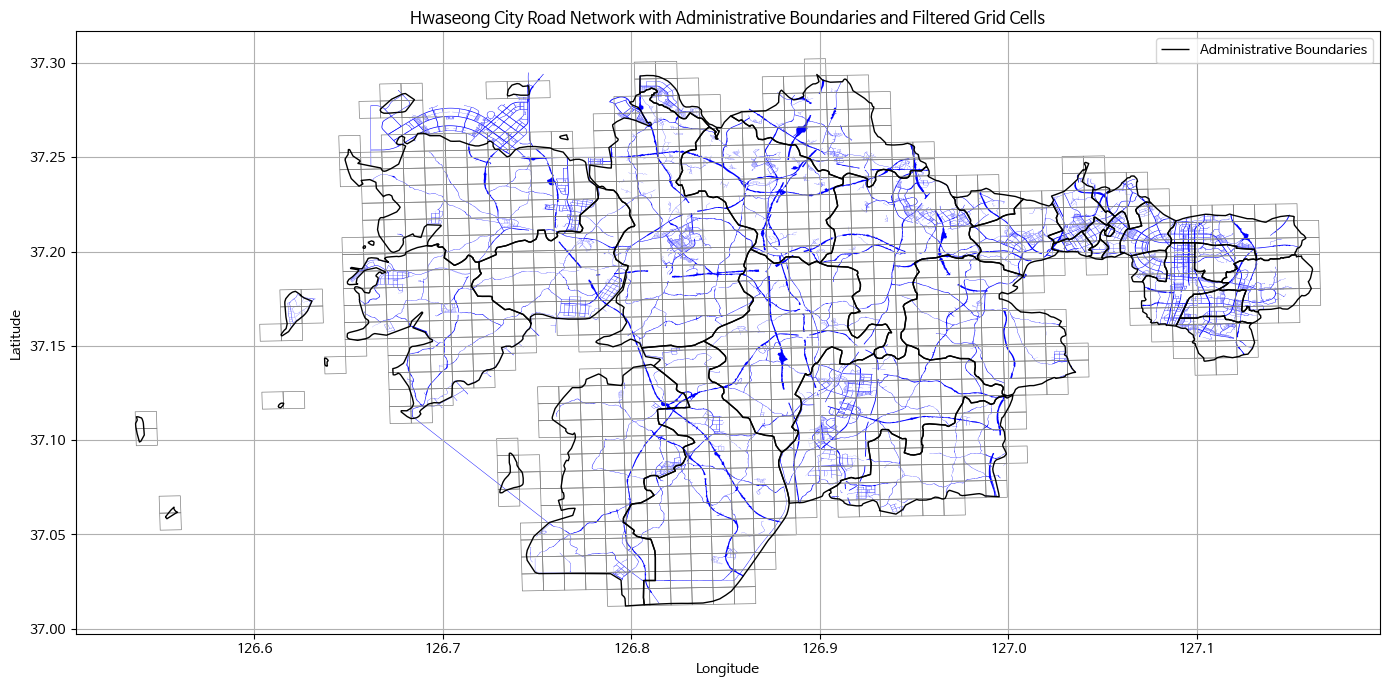

In [33]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Shapefile 및 행정동 경계 데이터 불러오기
shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
hwaseong_boundary_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson"

# Geopandas로 도로 데이터 읽기
gdf = gpd.read_file(shapefile_path, encoding='euc-kr')

# 화성시 도로 데이터 필터링
hwaseong_gdf = gdf[gdf['SIGNGU_SE'] == '41590']

# 행정동 경계 데이터 불러오기
boundary_gdf = gpd.read_file(hwaseong_boundary_path, encoding='utf-8')
boundary_gdf = boundary_gdf[boundary_gdf['sggnm'].str.contains('화성시')]

# 좌표계 변환 (도로, 경계 데이터 모두 동일한 좌표계로 변환)
hwaseong_gdf = hwaseong_gdf.to_crs(epsg=32652)
boundary_gdf = boundary_gdf.to_crs(epsg=32652)

# 그리드 데이터 생성 (1km x 1km)
xmin, ymin, xmax, ymax = boundary_gdf.total_bounds
cell_size = 1000  # 1km
cols = list(np.arange(xmin, xmax, cell_size))
rows = list(np.arange(ymin, ymax, cell_size))
grid_cells = []

for x in cols:
    for y in rows:
        grid_cell = Polygon([(x, y), (x + cell_size, y), (x + cell_size, y + cell_size), (x, y + cell_size)])
        grid_cells.append(grid_cell)

# 그리드 GeoDataFrame 생성
grid_gdf = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs='EPSG:32652')
grid_gdf['grid_id'] = range(len(grid_gdf))

# 공간 인덱스를 사용하여 화성시 경계와 교차하는 그리드 필터링
boundary_sindex = boundary_gdf.sindex  # 공간 인덱스 생성
filtered_grid_cells = []

for idx, grid_cell in enumerate(grid_gdf.geometry):
    possible_matches_index = list(boundary_sindex.intersection(grid_cell.bounds))
    possible_matches = boundary_gdf.iloc[possible_matches_index]
    if possible_matches.intersects(grid_cell).any():
        filtered_grid_cells.append(grid_cell)

# 필터링된 그리드 GeoDataFrame 생성
filtered_grid_gdf = gpd.GeoDataFrame(filtered_grid_cells, columns=['geometry'], crs='EPSG:32652')
filtered_grid_gdf['grid_id'] = range(len(filtered_grid_gdf))

# 시각화를 위해 좌표계를 EPSG:4326으로 변환 (위도/경도)
hwaseong_gdf = hwaseong_gdf.to_crs(epsg=4326)
boundary_gdf = boundary_gdf.to_crs(epsg=4326)
filtered_grid_gdf = filtered_grid_gdf.to_crs(epsg=4326)

# 시각화
fig, ax = plt.subplots(figsize=(14, 14))  # 크기 조정

# 도로 시각화
hwaseong_gdf.plot(ax=ax, color='blue', linewidth=0.5, label='Road Network')

# 행정동 경계 시각화
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=1.0, label='Administrative Boundaries')

# 필터링된 그리드 시각화
filtered_grid_gdf.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.5, label='Filtered Grid Cells')

# 그래프 설정
ax.set_aspect('equal')  # aspect를 'equal'로 설정하여 지도의 비율을 유지하도록 조정
plt.title("Hwaseong City Road Network with Administrative Boundaries and Filtered Grid Cells")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# **외부인 개방 충전소 데이터 분석**

<>:6: SyntaxWarning: invalid escape sequence '\Z'
<>:6: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\1030356808.py:6: SyntaxWarning: invalid escape sequence '\Z'
  shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


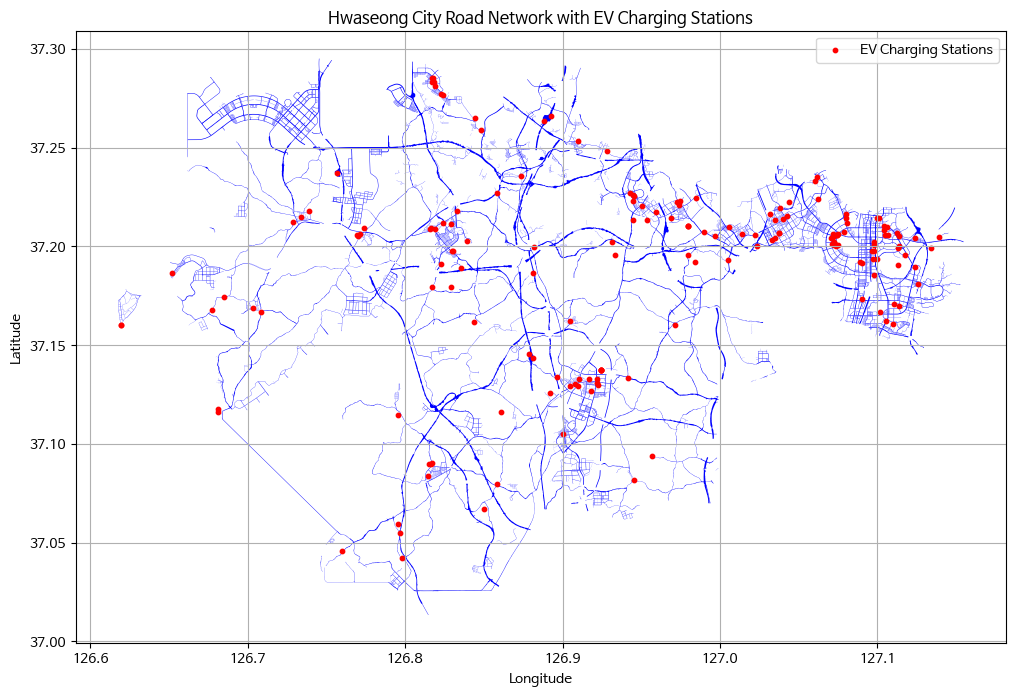

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Shapefile 경로 설정
shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
charging_station_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전기차충전소현황_이름_위치_위경도_운영시간_주차가능대수.csv"

# Geopandas로 도로 데이터 읽기 (인코딩 문제 해결을 위해 encoding='euc-kr' 추가)
gdf = gpd.read_file(shapefile_path, encoding='euc-kr')

# 화성시 (행정구역 코드: 41590) 도로 데이터 필터링
hwaseong_gdf = gdf[gdf['SIGNGU_SE'] == '41590']

# 도로 데이터만 필터링 (가정: 도로 관련 컬럼 이름이 'DGM_NM' 또는 유사한 경우, 예를 들어 '소로', '중로', '대로' 등이 포함된 경우)
road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('소로|중로|대로|광로', na=False)]  # na=False로 NaN 값 처리

# 위도/경도 좌표계로 변환 (EPSG:4326)
road_gdf = road_gdf.to_crs(epsg=4326)

# 전기차 충전소 데이터 읽기
charging_stations_df = pd.read_csv(charging_station_path)

# 충전소 위치 데이터 추출 (위도와 경도 컬럼 사용 가정)
charging_stations = charging_stations_df[['위도', '경도']]

# 도로 데이터 시각화 (필터링 후 실행)
plt.figure(figsize=(12, 12))
ax = plt.gca()
road_gdf.plot(ax=ax, color='blue', linewidth=0.5)  # EPSG:4326 좌표계로 변환하여 시각화

# 전기차 충전소 위치 시각화 (위도, 경도 기준으로 점 찍기)
plt.scatter(charging_stations['경도'], charging_stations['위도'], color='red', s=10, label='EV Charging Stations')

plt.title("Hwaseong City Road Network with EV Charging Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

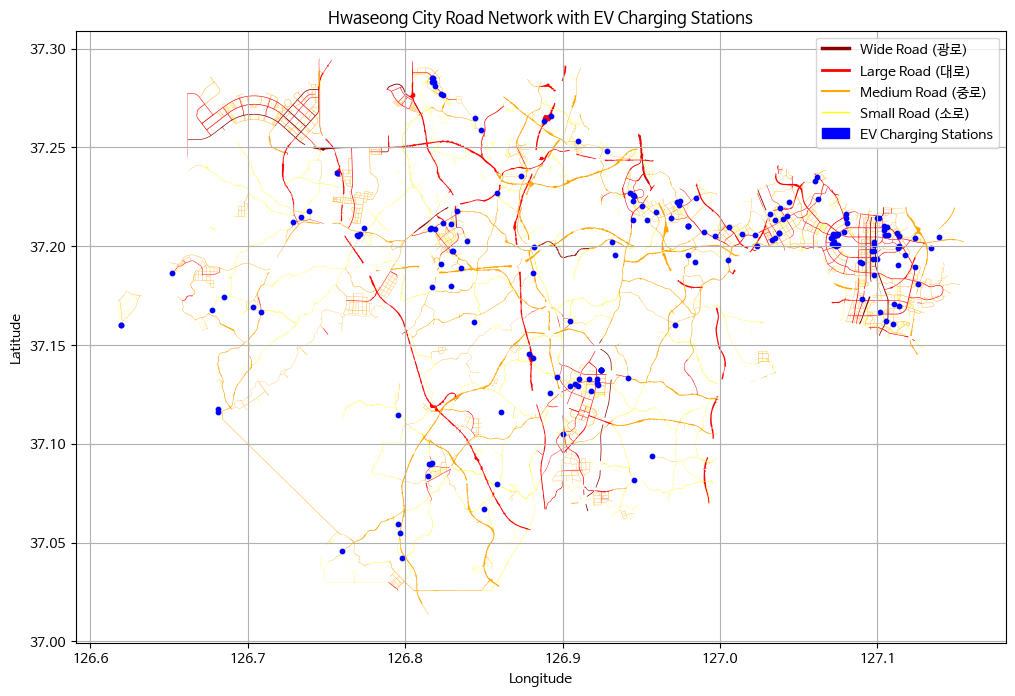

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


# 도로 데이터를 유형별로 필터링
small_road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('소로', na=False)]
medium_road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('중로', na=False)]
large_road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('대로', na=False)]
wide_road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('광로', na=False)]

# 위도/경도 좌표계로 변환 (EPSG:4326)
small_road_gdf = small_road_gdf.to_crs(epsg=4326)
medium_road_gdf = medium_road_gdf.to_crs(epsg=4326)
large_road_gdf = large_road_gdf.to_crs(epsg=4326)
wide_road_gdf = wide_road_gdf.to_crs(epsg=4326)

# 전기차 충전소 데이터 읽기
charging_stations_df = pd.read_csv(charging_station_path)

# 충전소 위치 데이터 추출 (위도와 경도 컬럼 사용 가정)
charging_stations = charging_stations_df[['위도', '경도']]

# 도로 데이터 시각화 (필터링 후 실행)
plt.figure(figsize=(12, 12))
ax = plt.gca()

# 도로 유형별로 시각화 (광로는 가장 두껍고, 소로는 가장 얇게)
wide_road_gdf.plot(ax=ax, color='darkred', linewidth=2.5)
large_road_gdf.plot(ax=ax, color='red', linewidth=2)
medium_road_gdf.plot(ax=ax, color='orange', linewidth=1.5)
small_road_gdf.plot(ax=ax, color='yellow', linewidth=1)

# 전기차 충전소 위치 시각화 (위도, 경도 기준으로 점 찍기)
plt.scatter(charging_stations['경도'], charging_stations['위도'], color='blue', s=10, label='EV Charging Stations')

# 맞춤형 범례 생성
wide_legend = mlines.Line2D([], [], color='darkred', linewidth=2.5, label='Wide Road (광로)')
large_legend = mlines.Line2D([], [], color='red', linewidth=2, label='Large Road (대로)')
medium_legend = mlines.Line2D([], [], color='orange', linewidth=1.5, label='Medium Road (중로)')
small_legend = mlines.Line2D([], [], color='yellow', linewidth=1, label='Small Road (소로)')
ev_legend = mpatches.Patch(color='blue', label='EV Charging Stations')

plt.legend(handles=[wide_legend, large_legend, medium_legend, small_legend, ev_legend])

plt.title("Hwaseong City Road Network with EV Charging Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


# **전체 충전소 데이터 분석**

c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터/Z_UPIS_C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


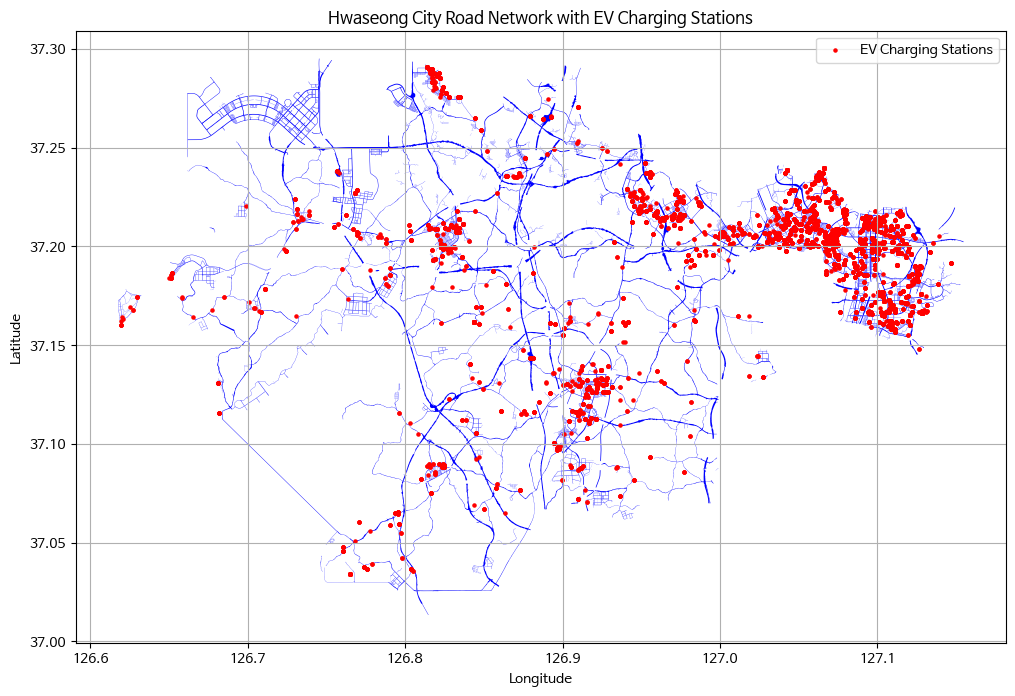

In [36]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Shapefile 경로 설정
shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터/Z_UPIS_C_UQ151.shp"
charging_station_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\화성시_전기차_충전소_좌표_완성본.csv"

# Geopandas로 도로 데이터 읽기 (인코딩 문제 해결을 위해 encoding='euc-kr' 추가)
gdf = gpd.read_file(shapefile_path, encoding='euc-kr')

# 화성시 (행정구역 코드: 41590) 도로 데이터 필터링
hwaseong_gdf = gdf[gdf['SIGNGU_SE'] == '41590']

# 도로 데이터만 필터링 (가정: 도로 관련 컬럼 이름이 'DGM_NM' 또는 유사한 경우, 예를 들어 '소로', '중로', '대로' 등이 포함된 경우)
road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('소로|중로|대로|광로', na=False)]  # na=False로 NaN 값 처리

# 위도/경도 좌표계로 변환 (EPSG:4326)
road_gdf = road_gdf.to_crs(epsg=4326)

# 전기차 충전소 데이터 읽기
charging_stations_df = pd.read_csv(charging_station_path)

# 충전소 위치 데이터 추출 (위도와 경도 컬럼 사용 가정)
charging_stations = charging_stations_df[['위도', '경도']]

# 도로 데이터 시각화 (필터링 후 실행)
plt.figure(figsize=(12, 12))
ax = plt.gca()
road_gdf.plot(ax=ax, color='blue', linewidth=0.5)  # EPSG:4326 좌표계로 변환하여 시각화

# 전기차 충전소 위치 시각화 (위도, 경도 기준으로 점 찍기)
plt.scatter(charging_stations['경도'], charging_stations['위도'], color='red', s=5, label='EV Charging Stations')

plt.title("Hwaseong City Road Network with EV Charging Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터/Z_UPIS_C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3462994050.py:44: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


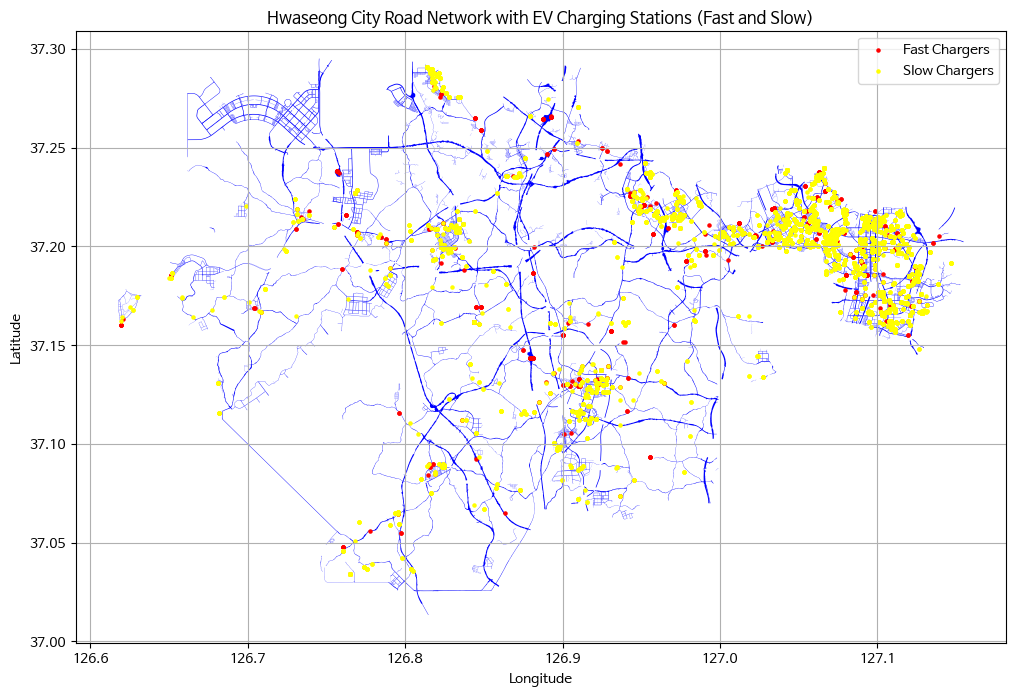

In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import re

# Shapefile 경로 설정
shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터/Z_UPIS_C_UQ151.shp"
charging_station_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\화성시_전기차_충전소_좌표_완성본.csv"

# Geopandas로 도로 데이터 읽기 (인코딩 문제 해결을 위해 encoding='euc-kr' 추가)
gdf = gpd.read_file(shapefile_path, encoding='euc-kr')

# 화성시 (행정구역 코드: 41590) 도로 데이터 필터링
hwaseong_gdf = gdf[gdf['SIGNGU_SE'] == '41590']

# 도로 데이터만 필터링 (가정: 도로 관련 컬럼 이름이 'DGM_NM' 또는 유사한 경우, 예를 들어 '소로', '중로', '대로' 등이 포함된 경우)
road_gdf = hwaseong_gdf[hwaseong_gdf['DGM_NM'].str.contains('소로|중로|대로|광로', na=False)]  # na=False로 NaN 값 처리

# 위도/경도 좌표계로 변환 (EPSG:4326)
road_gdf = road_gdf.to_crs(epsg=4326)

# 전기차 충전소 데이터 읽기
charging_stations_df = pd.read_csv(charging_station_path)

# 충전소 위치 시각화: '충전용량' 컬럼을 기준으로 급속과 완속을 구분
fast_chargers = charging_stations_df[charging_stations_df['충전용량'].str.contains('급속', flags=re.IGNORECASE, na=False)]
slow_chargers = charging_stations_df[charging_stations_df['충전용량'].str.contains('완속', flags=re.IGNORECASE, na=False)]

# 도로 데이터 시각화 (필터링 후 실행)
plt.figure(figsize=(12, 12))
ax = plt.gca()
road_gdf.plot(ax=ax, color='blue', linewidth=1, label='Road Network')

# 급속 충전기 위치 시각화
plt.scatter(fast_chargers['경도'], fast_chargers['위도'], color='red', s=5, label='Fast Chargers')

# 완속 충전기 위치 시각화
plt.scatter(slow_chargers['경도'], slow_chargers['위도'], color='yellow', s=5, label='Slow Chargers')

# 그래프 설정
plt.title("Hwaseong City Road Network with EV Charging Stations (Fast and Slow)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()


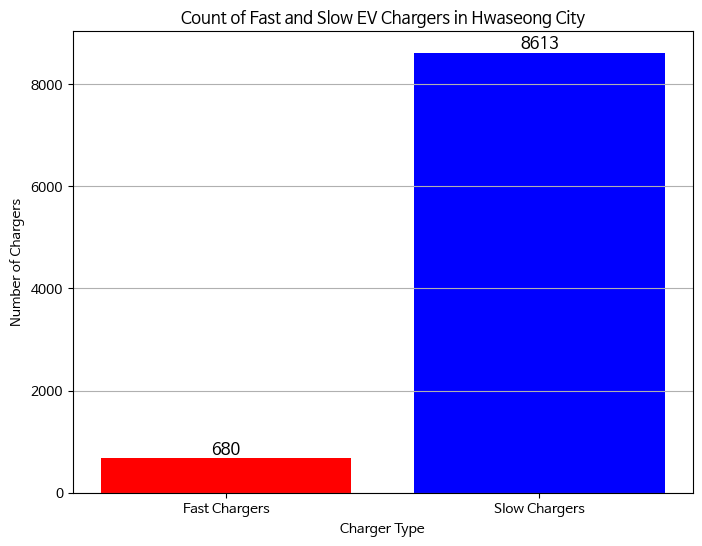

In [38]:
# 급속 및 완속 충전기 개수 막대 그래프
plt.figure(figsize=(8, 6))
counts = [len(fast_chargers), len(slow_chargers)]
labels = ['Fast Chargers', 'Slow Chargers']
bars = plt.bar(labels, counts, color=['red', 'blue'])

# 각 막대 위에 개수 표시
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontsize=12, color='black')

# 그래프 설정
plt.title("Count of Fast and Slow EV Chargers in Hwaseong City")
plt.xlabel("Charger Type")
plt.ylabel("Number of Chargers")
plt.grid(axis='y')
plt.show()



In [39]:
df_finally = pd.read_csv("G:\내 드라이브\화성 데이터 공모전\데이터파일\행정동별 경계, 인구, 면적, 인구밀집도, 유동인구,전기차 등록대수.csv",encoding="cp949")
df_finally

,Unnamed: 0,행정구역,geometry,인구수,면적,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차 등록대수,자동차 등록현황
0,18,경기도 화성시 기배동,MULTIPOLYGON (((126.99758056517456 37.23023237...,16109,4253652.2,0.003787,1411.634808,1405.393590,213,9083
1,3,경기도 화성시 남양읍,MULTIPOLYGON (((126.84096961190143 37.26592072...,55133,67406090.6,0.000818,8418.973051,7289.849734,938,39912
2,21,경기도 화성시 동탄1동,MULTIPOLYGON (((127.07558339692721 37.22589990...,50476,5300000.0,0.009524,7624.793291,7048.853046,524,22301
3,20,경기도 화성시 동탄2동,MULTIPOLYGON (((127.08347298241424 37.20047576...,34380,2200000.0,0.015627,2975.525727,3166.017579,347,14783
4,22,경기도 화성시 동탄3동,MULTIPOLYGON (((127.06437508597052 37.21207579...,40912,2459807.1,0.016632,3240.372547,3389.251959,413,17589
5,25,경기도 화성시 동탄4동,MULTIPOLYGON (((127.09892058992234 37.20474996...,53389,4236978.7,0.012601,3206.740316,3509.937520,552,23485
6,24,경기도 화성시 동탄5동,MULTIPOLYGON (((127.08896314367269 37.21635856...,46746,11410447.3,0.004097,5117.916451,4681.333513,585,24881
7,13,경기도 화성시 동탄6동,MULTIPOLYGON (((127.09101567294364 37.16477925...,43247,9489892.8,0.004557,5451.240370,5117.507342,531,22588
8,26,경기도 화성시 동탄7동,MULTIPOLYGON (((127.11151380817074 37.18001895...,56758,4726993.8,0.012007,5392.229904,5680.017007,638,27130
9,27,경기도 화성시 동탄8동,MULTIPOLYGON (((127.08895355840001 37.16052454...,33572,6534144.3,0.005138,2732.131803,2988.463681,413,17591


# **클러스터링을 통해 행정동 추출**

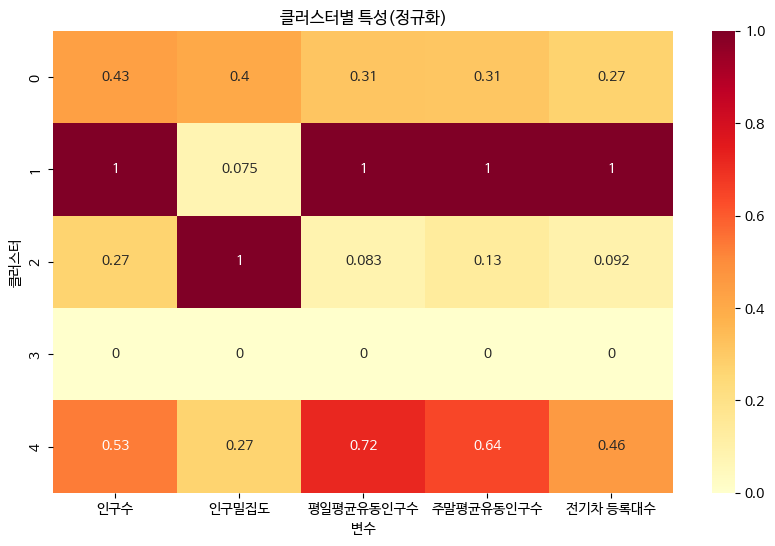

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 사용할 변수(피처) 선정
features = ['인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수', '전기차 등록대수']  # 실제 컬럼명에 맞게 수정
X = df_finally[features].fillna(0)

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. KMeans 클러스터링
n_clusters = 5  
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_finally['클러스터'] = labels

# 4. 클러스터별 평균값 (원본 값)
cluster_means = df_finally.groupby('클러스터')[features].mean()

# 5. 클러스터별 평균값 (정규화 값)
scaler2 = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    scaler2.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

# 6. 히트맵 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_scaled, annot=True, cmap='YlOrRd')
plt.title('클러스터별 특성(정규화)')
plt.ylabel('클러스터')
plt.xlabel('변수')
plt.show()



In [61]:
for i in sorted(df_finally['클러스터'].unique()):
    print(f"[클러스터 {i}]")
    print(df_finally[df_finally['클러스터']==i]['행정구역'].values)


[클러스터 0]
['경기도 화성시 동탄4동' '경기도 화성시 동탄5동' '경기도 화성시 동탄6동' '경기도 화성시 동탄7동'
 '경기도 화성시 동탄8동' '경기도 화성시 동탄9동' '경기도 화성시 반월동' '경기도 화성시 진안동']
[클러스터 1]
['경기도 화성시 봉담읍' '경기도 화성시 향남읍']
[클러스터 2]
['경기도 화성시 동탄2동' '경기도 화성시 동탄3동' '경기도 화성시 병점1동' '경기도 화성시 병점2동' '경기도 화성시 새솔동']
[클러스터 3]
['경기도 화성시 기배동' '경기도 화성시 마도면' '경기도 화성시 매송면' '경기도 화성시 비봉면' '경기도 화성시 서신면'
 '경기도 화성시 송산면' '경기도 화성시 양감면' '경기도 화성시 우정읍' '경기도 화성시 장안면' '경기도 화성시 정남면'
 '경기도 화성시 팔탄면' '경기도 화성시 화산동']
[클러스터 4]
['경기도 화성시 남양읍' '경기도 화성시 동탄1동']


In [69]:
df_clusterd_dong = df_finally[df_finally['클러스터'].isin([4, 1])]
df_clusterd_dong['행정구역']

1      경기도 화성시 남양읍
2     경기도 화성시 동탄1동
16     경기도 화성시 봉담읍
27     경기도 화성시 향남읍
Name: 행정구역, dtype: object

In [75]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon

# 데이터 경로 설정
shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
boundary_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson"
admin_data_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\행정동별 경계, 인구, 면적, 인구밀집도, 유동인구,전기차 등록대수.csv"

# 도로 및 행정동 경계 데이터 불러오기
gdf = gpd.read_file(shapefile_path, encoding='euc-kr')
boundary_gdf = gpd.read_file(boundary_path, encoding='utf-8')
admin_df = pd.read_csv(admin_data_path, encoding='cp949')

# 화성시 필터링 (도로와 경계 모두)
hwaseong_gdf = gdf[gdf['SIGNGU_SE'] == '41590']
boundary_gdf = boundary_gdf[boundary_gdf['sggnm'].str.contains('화성시')]

# 좌표계 변환 (EPSG:32652, UTM)
hwaseong_gdf = hwaseong_gdf.to_crs(epsg=32652)
boundary_gdf = boundary_gdf.to_crs(epsg=32652)

# 그리드 데이터 생성 (1km x 1km)
xmin, ymin, xmax, ymax = boundary_gdf.total_bounds
cell_size = 1000  # 1km
cols = list(np.arange(xmin, xmax, cell_size))
rows = list(np.arange(ymin, ymax, cell_size))

# 그리드 셀 생성
grid_cells = []
for x in cols:
    for y in rows:
        grid_cell = Polygon([(x, y), (x + cell_size, y), (x + cell_size, y + cell_size), (x, y + cell_size)])
        grid_cells.append(grid_cell)

# 그리드 GeoDataFrame 생성
grid_gdf = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs='EPSG:32652')
grid_gdf['grid_id'] = range(len(grid_gdf))

# 화성시 경계와 교차하는 그리드만 필터링하여 filtered_grid_gdf 생성
filtered_grid_gdf = gpd.sjoin(grid_gdf, boundary_gdf, how='inner', predicate='intersects')
filtered_grid_gdf = filtered_grid_gdf.drop(columns=['index_right'])

# 각 그리드에 인구, 인구밀도, 유동인구 할당
filtered_grid_gdf['인구수'] = 0
filtered_grid_gdf['인구밀집도'] = 0.0
filtered_grid_gdf['평일평균유동인구수'] = 0
filtered_grid_gdf['주말평균유동인구수'] = 0
filtered_grid_gdf['전기차등록대수'] = 0

# 행정동 경계와 그리드의 교차를 통해 각 변수 할당
for idx, grid in filtered_grid_gdf.iterrows():
    intersecting_admins = boundary_gdf[boundary_gdf.intersects(grid['geometry'])]
    for _, admin in intersecting_admins.iterrows():
        admin_data = admin_df[admin_df['행정구역'] == admin['adm_nm']]
        if not admin_data.empty:
            intersection_area = grid['geometry'].intersection(admin['geometry']).area
            admin_area = admin['geometry'].area
            weight = intersection_area / admin_area
            filtered_grid_gdf.at[idx, '인구수'] += admin_data['인구수'].values[0] * weight
            filtered_grid_gdf.at[idx, '인구밀집도'] += admin_data['인구밀집도'].values[0] * weight
            filtered_grid_gdf.at[idx, '평일평균유동인구수'] += admin_data['평일평균유동인구수'].values[0] * weight
            filtered_grid_gdf.at[idx, '주말평균유동인구수'] += admin_data['주말평균유동인구수'].values[0] * weight
            filtered_grid_gdf.at[idx, '전기차등록대수'] += admin_data['전기차 등록대수'].values[0] * weight

target_list = ["남양읍", "향남읍", "동탄1동", "봉담읍"]
pattern = "|".join(target_list)
filtered_grid_gdf[filtered_grid_gdf["adm_nm"].str.contains(pattern)]

# 결과 데이터프레임 출력


<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:8: SyntaxWarning: invalid escape sequence '\H'
<>:7: SyntaxWarning: invalid escape sequence '\Z'
<>:8: SyntaxWarning: invalid escape sequence '\H'
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3787033229.py:7: SyntaxWarning: invalid escape sequence '\Z'
  shapefile_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp"
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3787033229.py:8: SyntaxWarning: invalid escape sequence '\H'
  boundary_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson"
c:\Users\SEUNGJUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: G:\내 드라이브\화성 데이터 공모전\데이터파일\전국도로데이터\Z_UPIS_C_UQ151.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3787033229.py:61: FutureWarning:

,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수
687,"POLYGON ((302149.774 4113479.324, 303149.774 4...",687,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,25.452853,3.776046e-07,3.886726,3.365452,0.433040
696,"POLYGON ((302149.774 4122479.324, 303149.774 4...",696,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,369.974728,6.330165e-06,55.077381,51.343961,6.996008
697,"POLYGON ((302149.774 4123479.324, 303149.774 4...",697,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,583.335842,9.216721e-06,88.128309,78.751897,10.393615
719,"POLYGON ((303149.774 4113479.324, 304149.774 4...",719,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,451.684397,6.700943e-06,68.973551,59.723058,7.684689
720,"POLYGON ((303149.774 4114479.324, 304149.774 4...",720,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,28.606141,4.243851e-07,4.368243,3.782389,0.486688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,"POLYGON ((329149.774 4120479.324, 330149.774 4...",1558,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,7144.143340,1.347952e-03,1079.178544,997.662583,74.164575
1559,"POLYGON ((329149.774 4121479.324, 330149.774 4...",1559,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,1058.580716,2.171461e-04,163.319804,136.826956,11.335026
1588,"POLYGON ((330149.774 4118479.324, 331149.774 4...",1588,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,13697.079548,1.423815e-03,1695.324673,1585.065206,168.243553
1589,"POLYGON ((330149.774 4119479.324, 331149.774 4...",1589,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,8998.579810,9.166940e-04,1037.891197,951.224611,109.908286


In [40]:
filtered_grid_gdf

,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수
10,"POLYGON ((281149.774 4108479.324, 282149.774 4...",10,경기도 화성시 우정읍,4159025600,41590,41,경기도,화성시,31240130,57.817704,9.374652e-07,10.615093,8.089801,1.143822
11,"POLYGON ((281149.774 4109479.324, 282149.774 4...",11,경기도 화성시 우정읍,4159025600,41590,41,경기도,화성시,31240130,61.341955,9.946079e-07,11.262131,8.582911,1.213543
37,"POLYGON ((282149.774 4103479.324, 283149.774 4...",37,경기도 화성시 우정읍,4159025600,41590,41,경기도,화성시,31240130,21.964510,3.561360e-07,4.032594,3.073254,0.434529
38,"POLYGON ((282149.774 4104479.324, 283149.774 4...",38,경기도 화성시 우정읍,4159025600,41590,41,경기도,화성시,31240130,18.009106,2.920024e-07,3.306398,2.519818,0.356279
204,"POLYGON ((287149.774 4110479.324, 288149.774 4...",204,경기도 화성시 서신면,4159035000,41590,41,경기도,화성시,31240370,6.849193,1.574796e-07,1.212463,1.854648,0.148268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,"POLYGON ((336149.774 4115479.324, 337149.774 4...",1777,경기도 화성시 동탄9동,4159063000,41590,41,경기도,화성시,31240720,777.999177,7.806454e-05,78.909681,76.241643,10.054082
1778,"POLYGON ((336149.774 4116479.324, 337149.774 4...",1778,경기도 화성시 동탄9동,4159063000,41590,41,경기도,화성시,31240720,2101.799464,2.108948e-04,213.178022,205.970196,27.161551
1779,"POLYGON ((336149.774 4117479.324, 337149.774 4...",1779,경기도 화성시 동탄9동,4159063000,41590,41,경기도,화성시,31240720,1534.594137,1.539814e-04,155.648409,150.385734,19.831557
1780,"POLYGON ((336149.774 4118479.324, 337149.774 4...",1780,경기도 화성시 동탄5동,4159059000,41590,41,경기도,화성시,31240650,482.820681,4.231391e-05,52.860906,48.351616,6.042230


In [76]:
filtered_grid_gdf_dong = filtered_grid_gdf[filtered_grid_gdf["adm_nm"].str.contains(pattern)]
filtered_grid_gdf_dong

,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수
687,"POLYGON ((302149.774 4113479.324, 303149.774 4...",687,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,25.452853,3.776046e-07,3.886726,3.365452,0.433040
696,"POLYGON ((302149.774 4122479.324, 303149.774 4...",696,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,369.974728,6.330165e-06,55.077381,51.343961,6.996008
697,"POLYGON ((302149.774 4123479.324, 303149.774 4...",697,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,583.335842,9.216721e-06,88.128309,78.751897,10.393615
719,"POLYGON ((303149.774 4113479.324, 304149.774 4...",719,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,451.684397,6.700943e-06,68.973551,59.723058,7.684689
720,"POLYGON ((303149.774 4114479.324, 304149.774 4...",720,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,28.606141,4.243851e-07,4.368243,3.782389,0.486688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,"POLYGON ((329149.774 4120479.324, 330149.774 4...",1558,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,7144.143340,1.347952e-03,1079.178544,997.662583,74.164575
1559,"POLYGON ((329149.774 4121479.324, 330149.774 4...",1559,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,1058.580716,2.171461e-04,163.319804,136.826956,11.335026
1588,"POLYGON ((330149.774 4118479.324, 331149.774 4...",1588,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,13697.079548,1.423815e-03,1695.324673,1585.065206,168.243553
1589,"POLYGON ((330149.774 4119479.324, 331149.774 4...",1589,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,8998.579810,9.166940e-04,1037.891197,951.224611,109.908286


<>:8: SyntaxWarning: invalid escape sequence '\H'
<>:8: SyntaxWarning: invalid escape sequence '\H'
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\1542962626.py:8: SyntaxWarning: invalid escape sequence '\H'
  boundary_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson"
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\1542962626.py:36: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


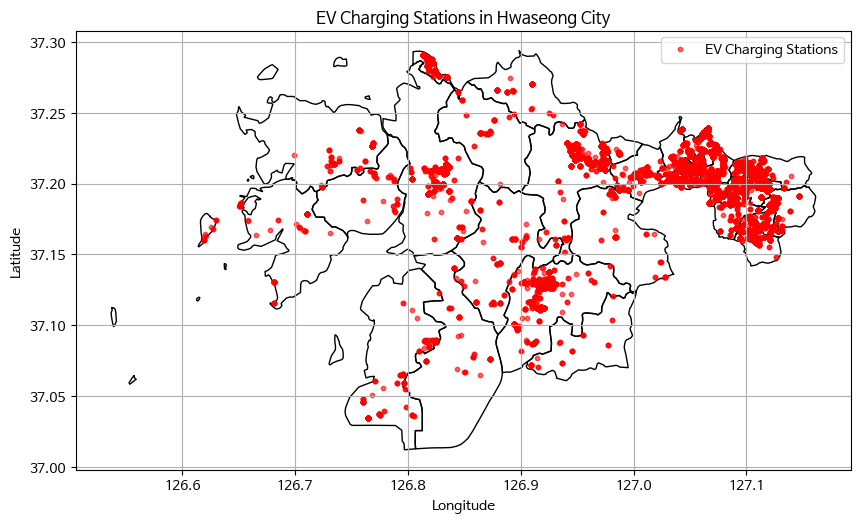

In [77]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# 데이터 경로 설정
ev_station_data_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\화성시_전기차_충전소_좌표_완성본.csv"
boundary_path = "G:\내 드라이브\화성 데이터 공모전\데이터파일\HangJeongDong_ver20241001.geojson"

# 전기차 충전소 데이터 불러오기
ev_station_df = pd.read_csv(ev_station_data_path, encoding='utf-8')

# 위도, 경도 열을 사용하여 Point 객체 생성 (열 이름 확인 필요)
ev_station_df['geometry'] = ev_station_df.apply(lambda row: Point(row['경도'], row['위도']), axis=1)

# GeoDataFrame으로 변환
ev_station_gdf = gpd.GeoDataFrame(ev_station_df, geometry='geometry', crs='EPSG:4326')

# 화성시 행정동 경계 데이터 불러오기 (배경 지도용)
boundary_gdf = gpd.read_file(boundary_path, encoding='utf-8')
boundary_gdf = boundary_gdf[boundary_gdf['sggnm'].str.contains('화성시')]
boundary_gdf = boundary_gdf.to_crs(epsg=4326)  # 위도/경도 좌표계로 변환

# 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 행정동 경계 시각화
boundary_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=1.0, label='Administrative Boundaries')

# 전기차 충전소 시각화
ev_station_gdf.plot(ax=ax, color='red', markersize=10, label='EV Charging Stations', alpha=0.6)

plt.title("EV Charging Stations in Hwaseong City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()


                                              geometry  grid_id       adm_nm  \
10   POLYGON ((281149.774 4108479.324, 282149.774 4...       10  경기도 화성시 우정읍   
11   POLYGON ((281149.774 4109479.324, 282149.774 4...       11  경기도 화성시 우정읍   
37   POLYGON ((282149.774 4103479.324, 283149.774 4...       37  경기도 화성시 우정읍   
38   POLYGON ((282149.774 4104479.324, 283149.774 4...       38  경기도 화성시 우정읍   
204  POLYGON ((287149.774 4110479.324, 288149.774 4...      204  경기도 화성시 서신면   

        adm_cd2    sgg sido sidonm sggnm    adm_cd        인구수         인구밀집도  \
10   4159025600  41590   41    경기도   화성시  31240130  57.817704  9.374652e-07   
11   4159025600  41590   41    경기도   화성시  31240130  61.341955  9.946079e-07   
37   4159025600  41590   41    경기도   화성시  31240130  21.964510  3.561360e-07   
38   4159025600  41590   41    경기도   화성시  31240130  18.009106  2.920024e-07   
204  4159035000  41590   41    경기도   화성시  31240370   6.849193  1.574796e-07   

     평일평균유동인구수  주말평균유동인구수   전기차등록대수  
10   1

C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\959642704.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


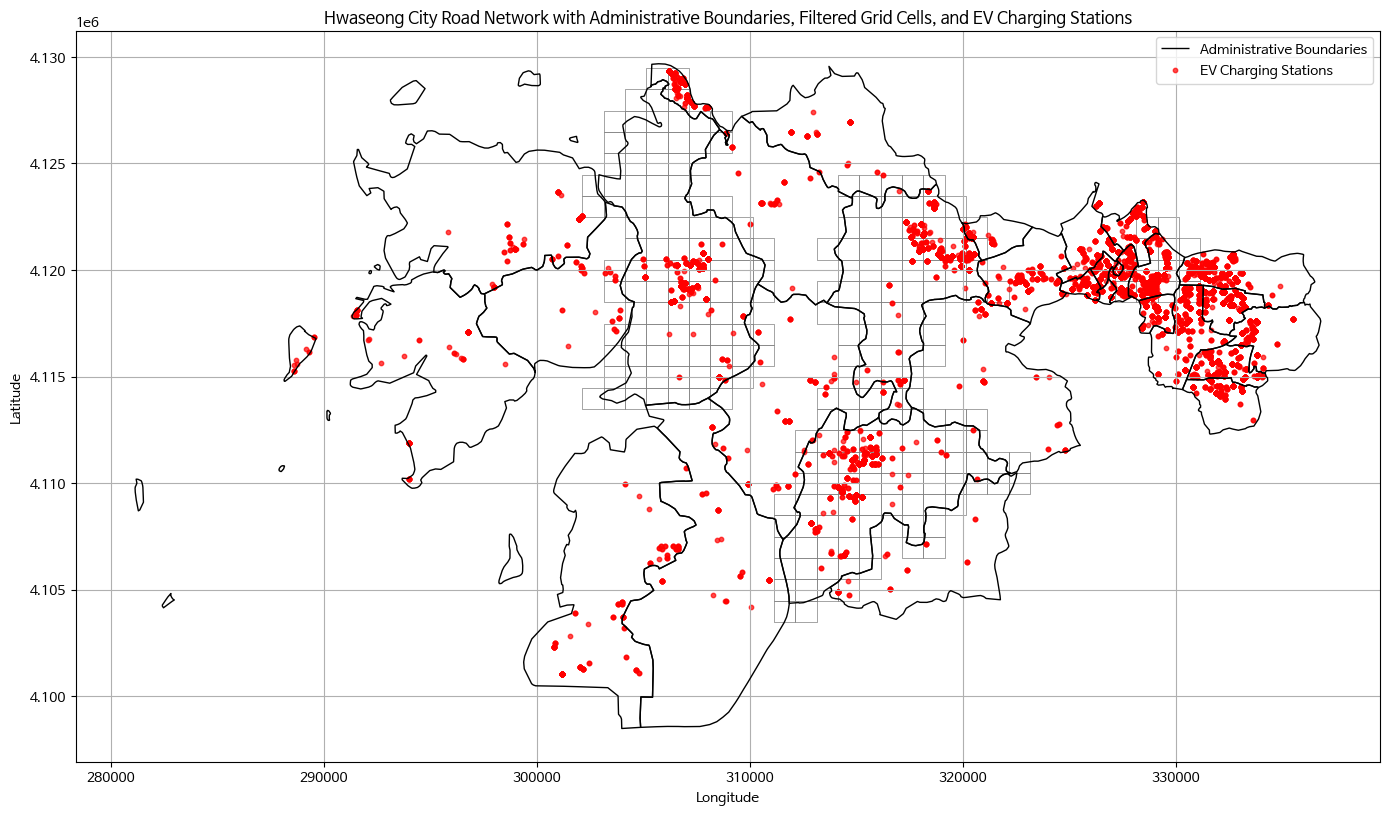

In [78]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon, Point


# 행정동 경계 데이터 불러오기
boundary_gdf = gpd.read_file(boundary_path, encoding='utf-8')

# 화성시 필터링 (행정동 경계)
boundary_gdf = boundary_gdf[boundary_gdf['sggnm'].str.contains('화성시')]

# 좌표계 변환 (EPSG:32652, UTM)
boundary_gdf = boundary_gdf.to_crs(epsg=32652)

# 기존에 생성한 그리드 데이터 사용 (1km x 1km)
# 이 코드는 그리드 생성 과정을 다시 포함하지 않고 기존 그리드를 사용합니다.

# 전기차 충전소 데이터만 불러오기
ev_station_df = pd.read_csv(ev_station_data_path, encoding='utf-8')

# 전기차 충전소 데이터에서 위도, 경도를 사용하여 포인트 생성
ev_station_df['geometry'] = ev_station_df.apply(lambda row: Point(row['경도'], row['위도']), axis=1)

# GeoDataFrame으로 변환
# 좌표계를 그리드와 동일하게 변환
ev_station_gdf = gpd.GeoDataFrame(ev_station_df, geometry='geometry', crs='EPSG:4326')
ev_station_gdf = ev_station_gdf.to_crs(epsg=32652)


# 결과 데이터프레임 출력
print(filtered_grid_gdf.head())

# 시각화
plt.figure(figsize=(14, 14))
ax = plt.gca()

# 행정동 경계 시각화
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=1.0, label='Administrative Boundaries')

# 필터링된 그리드 시각화
filtered_grid_gdf_dong.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.5, label='Filtered Grid Cells')

# 전기차 충전소 위치 시각화
ev_station_gdf.plot(ax=ax, color='red', markersize=10, label='EV Charging Stations', alpha=0.7)

# 그래프 설정
ax.set_aspect('equal')  # aspect를 'equal'로 설정하여 지도의 비율을 유지하도록 조정
plt.title("Hwaseong City Road Network with Administrative Boundaries, Filtered Grid Cells, and EV Charging Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [79]:
from shapely.geometry import Point
import geopandas as gpd

# 충전소 포인트 생성 (경도, 위도 순서)
jebudo_charging_station = Point(126.6193547, 37.15997353)  # 위도, 경도를 그대로 사용하면 됩니다.

# 포인트를 GeoDataFrame으로 변환 (EPSG:4326, WGS 84)
jebudo_gdf = gpd.GeoDataFrame([{'geometry': jebudo_charging_station}], crs='EPSG:4326')

# 그리드와 동일한 좌표계로 변환 (EPSG:32652, UTM)
jebudo_gdf = jebudo_gdf.to_crs(epsg=32652)

# 그리드 데이터프레임이 있는 것으로 가정 (filtered_grid_gdf)
# Point가 어느 그리드에 포함되는지 확인
result = filtered_grid_gdf[filtered_grid_gdf.contains(jebudo_gdf.iloc[0].geometry)]

# 결과 출력
if not result.empty:
    print("제부도 충전소가 속한 그리드의 정보:")
    print(result[['grid_id']])
else:
    print("제부도 충전소가 어떤 그리드에도 포함되지 않았습니다.")


제부도 충전소가 속한 그리드의 정보:
     grid_id
240      240


In [80]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 충전소 데이터 불러오기
ev_station_data_path = 'G:\내 드라이브\화성 데이터 공모전\데이터파일\화성시_전기차_충전소_좌표_완성본.csv'
ev_station_df = pd.read_csv(ev_station_data_path, encoding='utf-8')

# 충전소 좌표로 포인트 생성 (경도, 위도 순서)
ev_station_df['geometry'] = ev_station_df.apply(lambda row: Point(row['경도'], row['위도']), axis=1)

# 충전소 GeoDataFrame으로 변환 (초기 좌표계 EPSG:4326, WGS 84)
ev_station_gdf = gpd.GeoDataFrame(ev_station_df, geometry='geometry', crs='EPSG:4326')

# 충전소 GeoDataFrame 좌표계를 그리드와 동일하게 변환 (EPSG:32652, UTM)
ev_station_gdf = ev_station_gdf.to_crs(epsg=32652)

# 각 충전소에 대해 grid_id 찾기 위한 반복문
charging_station_grids = []

# 모든 충전소 데이터로부터 포인트 생성 및 변환
for idx, row in ev_station_gdf.iterrows():
    charging_point = row['geometry']

    # 충전소 포인트가 어느 그리드에 포함되는지 확인
    result = filtered_grid_gdf_dong[filtered_grid_gdf_dong.contains(charging_point)]

    # grid_id 결과 저장
    if not result.empty:
        grid_id = result.iloc[0]['grid_id']
        charging_station_grids.append({'충전소': row['충전소'], 'grid_id': grid_id})
    else:
        charging_station_grids.append({'충전소': row['충전소'], 'grid_id': None})

# 결과 DataFrame으로 변환 및 출력
charging_station_grids_df = pd.DataFrame(charging_station_grids)
print(charging_station_grids_df)

# 결과를 CSV 파일로 저장 (필요 시)
charging_station_grids_df.to_csv('화성시_충전소_dong_그리드_매핑_결과.csv', encoding='utf-8', index=False)


            충전소  grid_id
0        남양읍사무소    822.0
1        남양읍사무소    822.0
2          노작공원   1557.0
3          노작공원   1557.0
4         동탄보건소   1526.0
...         ...      ...
9289  동탄역린스트라우스      NaN
9290  동탄역린스트라우스      NaN
9291  동탄역린스트라우스      NaN
9292  동탄역린스트라우스      NaN
9293  동탄역린스트라우스      NaN

[9294 rows x 2 columns]


In [81]:
# 각 충전소의 grid_id에 따라 그리드별 충전소 개수 계산
charging_station_counts = charging_station_grids_df.groupby('grid_id').size().reset_index(name='충전소_개수')

# 결과 출력
print(charging_station_counts.head())


   grid_id  충전소_개수
0    722.0       4
1    725.0      10
2    757.0      18
3    758.0       3
4    789.0       2


In [82]:
# 그리드 GeoDataFrame에 충전소 개수 병합
filtered_grid_gdf_dong = filtered_grid_gdf_dong.merge(charging_station_counts, on='grid_id', how='left')

# 병합 후 NaN 값을 0으로 채움 (충전소가 없는 그리드는 개수를 0으로 표시)
filtered_grid_gdf_dong['충전소_개수'] = filtered_grid_gdf_dong['충전소_개수'].fillna(0)

# 결과 출력
print(filtered_grid_gdf_dong[['grid_id', '충전소_개수']])

     grid_id  충전소_개수
0        687     0.0
1        696     0.0
2        697     0.0
3        719     0.0
4        720     0.0
..       ...     ...
253     1558    72.0
254     1559     0.0
255     1588   205.0
256     1589   106.0
257     1590     6.0

[258 rows x 2 columns]


In [83]:
filtered_grid_gdf_dong

,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수,충전소_개수
0,"POLYGON ((302149.774 4113479.324, 303149.774 4...",687,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,25.452853,3.776046e-07,3.886726,3.365452,0.433040,0.0
1,"POLYGON ((302149.774 4122479.324, 303149.774 4...",696,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,369.974728,6.330165e-06,55.077381,51.343961,6.996008,0.0
2,"POLYGON ((302149.774 4123479.324, 303149.774 4...",697,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,583.335842,9.216721e-06,88.128309,78.751897,10.393615,0.0
3,"POLYGON ((303149.774 4113479.324, 304149.774 4...",719,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,451.684397,6.700943e-06,68.973551,59.723058,7.684689,0.0
4,"POLYGON ((303149.774 4114479.324, 304149.774 4...",720,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,28.606141,4.243851e-07,4.368243,3.782389,0.486688,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,"POLYGON ((329149.774 4120479.324, 330149.774 4...",1558,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,7144.143340,1.347952e-03,1079.178544,997.662583,74.164575,72.0
254,"POLYGON ((329149.774 4121479.324, 330149.774 4...",1559,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,1058.580716,2.171461e-04,163.319804,136.826956,11.335026,0.0
255,"POLYGON ((330149.774 4118479.324, 331149.774 4...",1588,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,13697.079548,1.423815e-03,1695.324673,1585.065206,168.243553,205.0
256,"POLYGON ((330149.774 4119479.324, 331149.774 4...",1589,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,8998.579810,9.166940e-04,1037.891197,951.224611,109.908286,106.0


In [84]:
# filtered_grid_dong_final을 복사하여 사용
filtered_grid_dong_final = filtered_grid_gdf_dong.copy()

# 교통량 가중치가 포함된 데이터 (grid_traffic_weight)를 filtered_grid_dong_final과 병합
# 병합 기준은 'grid_id'이며, 교통량 가중치 열을 추가합니다.
filtered_grid_dong_final = filtered_grid_dong_final.merge(grid_traffic_weight[['grid_id', '최종_가중치_교통량']], on='grid_id', how='left')

# NaN 값을 0으로 채움 (교통량 가중치가 없는 그리드는 0으로 표시)
filtered_grid_dong_final['최종_가중치_교통량'] = filtered_grid_dong_final['최종_가중치_교통량'].fillna(0)

# 결과 출력
filtered_grid_dong_final[filtered_grid_dong_final['최종_가중치_교통량'] != 0]


,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수,충전소_개수,최종_가중치_교통량
0,"POLYGON ((302149.774 4113479.324, 303149.774 4...",687,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,25.452853,3.776046e-07,3.886726,3.365452,0.433040,0.0,40033.458378
1,"POLYGON ((302149.774 4122479.324, 303149.774 4...",696,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,369.974728,6.330165e-06,55.077381,51.343961,6.996008,0.0,84151.564189
2,"POLYGON ((302149.774 4123479.324, 303149.774 4...",697,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,583.335842,9.216721e-06,88.128309,78.751897,10.393615,0.0,105003.068178
3,"POLYGON ((303149.774 4113479.324, 304149.774 4...",719,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,451.684397,6.700943e-06,68.973551,59.723058,7.684689,0.0,76191.396082
4,"POLYGON ((303149.774 4114479.324, 304149.774 4...",720,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,28.606141,4.243851e-07,4.368243,3.782389,0.486688,0.0,33236.478550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,"POLYGON ((327149.774 4118479.324, 328149.774 4...",1492,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,45536.704522,1.663226e-02,4202.635163,4244.364579,462.533323,85.0,30000.000000
246,"POLYGON ((327149.774 4119479.324, 328149.774 4...",1493,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,69431.444508,2.693168e-02,5872.302765,6060.787947,709.243106,125.0,10000.000000
247,"POLYGON ((328149.774 4118479.324, 329149.774 4...",1524,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,21106.459110,5.272808e-03,2875.179383,2716.627151,217.711421,393.0,10000.000000
248,"POLYGON ((328149.774 4119479.324, 329149.774 4...",1525,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,30580.383916,6.319336e-03,4577.532614,4028.885848,322.347769,108.0,10000.000000


In [85]:
filtered_grid_gdf_dong.sort_values(by='grid_id')


,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수,충전소_개수
0,"POLYGON ((302149.774 4113479.324, 303149.774 4...",687,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,25.452853,3.776046e-07,3.886726,3.365452,0.433040,0.0
1,"POLYGON ((302149.774 4122479.324, 303149.774 4...",696,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,369.974728,6.330165e-06,55.077381,51.343961,6.996008,0.0
2,"POLYGON ((302149.774 4123479.324, 303149.774 4...",697,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,583.335842,9.216721e-06,88.128309,78.751897,10.393615,0.0
3,"POLYGON ((303149.774 4113479.324, 304149.774 4...",719,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,451.684397,6.700943e-06,68.973551,59.723058,7.684689,0.0
4,"POLYGON ((303149.774 4114479.324, 304149.774 4...",720,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,28.606141,4.243851e-07,4.368243,3.782389,0.486688,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,"POLYGON ((329149.774 4120479.324, 330149.774 4...",1558,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,7144.143340,1.347952e-03,1079.178544,997.662583,74.164575,72.0
254,"POLYGON ((329149.774 4121479.324, 330149.774 4...",1559,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,1058.580716,2.171461e-04,163.319804,136.826956,11.335026,0.0
255,"POLYGON ((330149.774 4118479.324, 331149.774 4...",1588,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,13697.079548,1.423815e-03,1695.324673,1585.065206,168.243553,205.0
256,"POLYGON ((330149.774 4119479.324, 331149.774 4...",1589,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,8998.579810,9.166940e-04,1037.891197,951.224611,109.908286,106.0


# **데이터 병합 및 시각화**

In [86]:
filtered_grid_dong_final

,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수,충전소_개수,최종_가중치_교통량
0,"POLYGON ((302149.774 4113479.324, 303149.774 4...",687,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,25.452853,3.776046e-07,3.886726,3.365452,0.433040,0.0,40033.458378
1,"POLYGON ((302149.774 4122479.324, 303149.774 4...",696,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,369.974728,6.330165e-06,55.077381,51.343961,6.996008,0.0,84151.564189
2,"POLYGON ((302149.774 4123479.324, 303149.774 4...",697,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,583.335842,9.216721e-06,88.128309,78.751897,10.393615,0.0,105003.068178
3,"POLYGON ((303149.774 4113479.324, 304149.774 4...",719,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,451.684397,6.700943e-06,68.973551,59.723058,7.684689,0.0,76191.396082
4,"POLYGON ((303149.774 4114479.324, 304149.774 4...",720,경기도 화성시 남양읍,4159026200,41590,41,경기도,화성시,31240150,28.606141,4.243851e-07,4.368243,3.782389,0.486688,0.0,33236.478550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,"POLYGON ((329149.774 4120479.324, 330149.774 4...",1558,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,7144.143340,1.347952e-03,1079.178544,997.662583,74.164575,72.0,0.000000
254,"POLYGON ((329149.774 4121479.324, 330149.774 4...",1559,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,1058.580716,2.171461e-04,163.319804,136.826956,11.335026,0.0,0.000000
255,"POLYGON ((330149.774 4118479.324, 331149.774 4...",1588,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,13697.079548,1.423815e-03,1695.324673,1585.065206,168.243553,205.0,0.000000
256,"POLYGON ((330149.774 4119479.324, 331149.774 4...",1589,경기도 화성시 동탄1동,4159058500,41590,41,경기도,화성시,31240610,8998.579810,9.166940e-04,1037.891197,951.224611,109.908286,106.0,0.000000


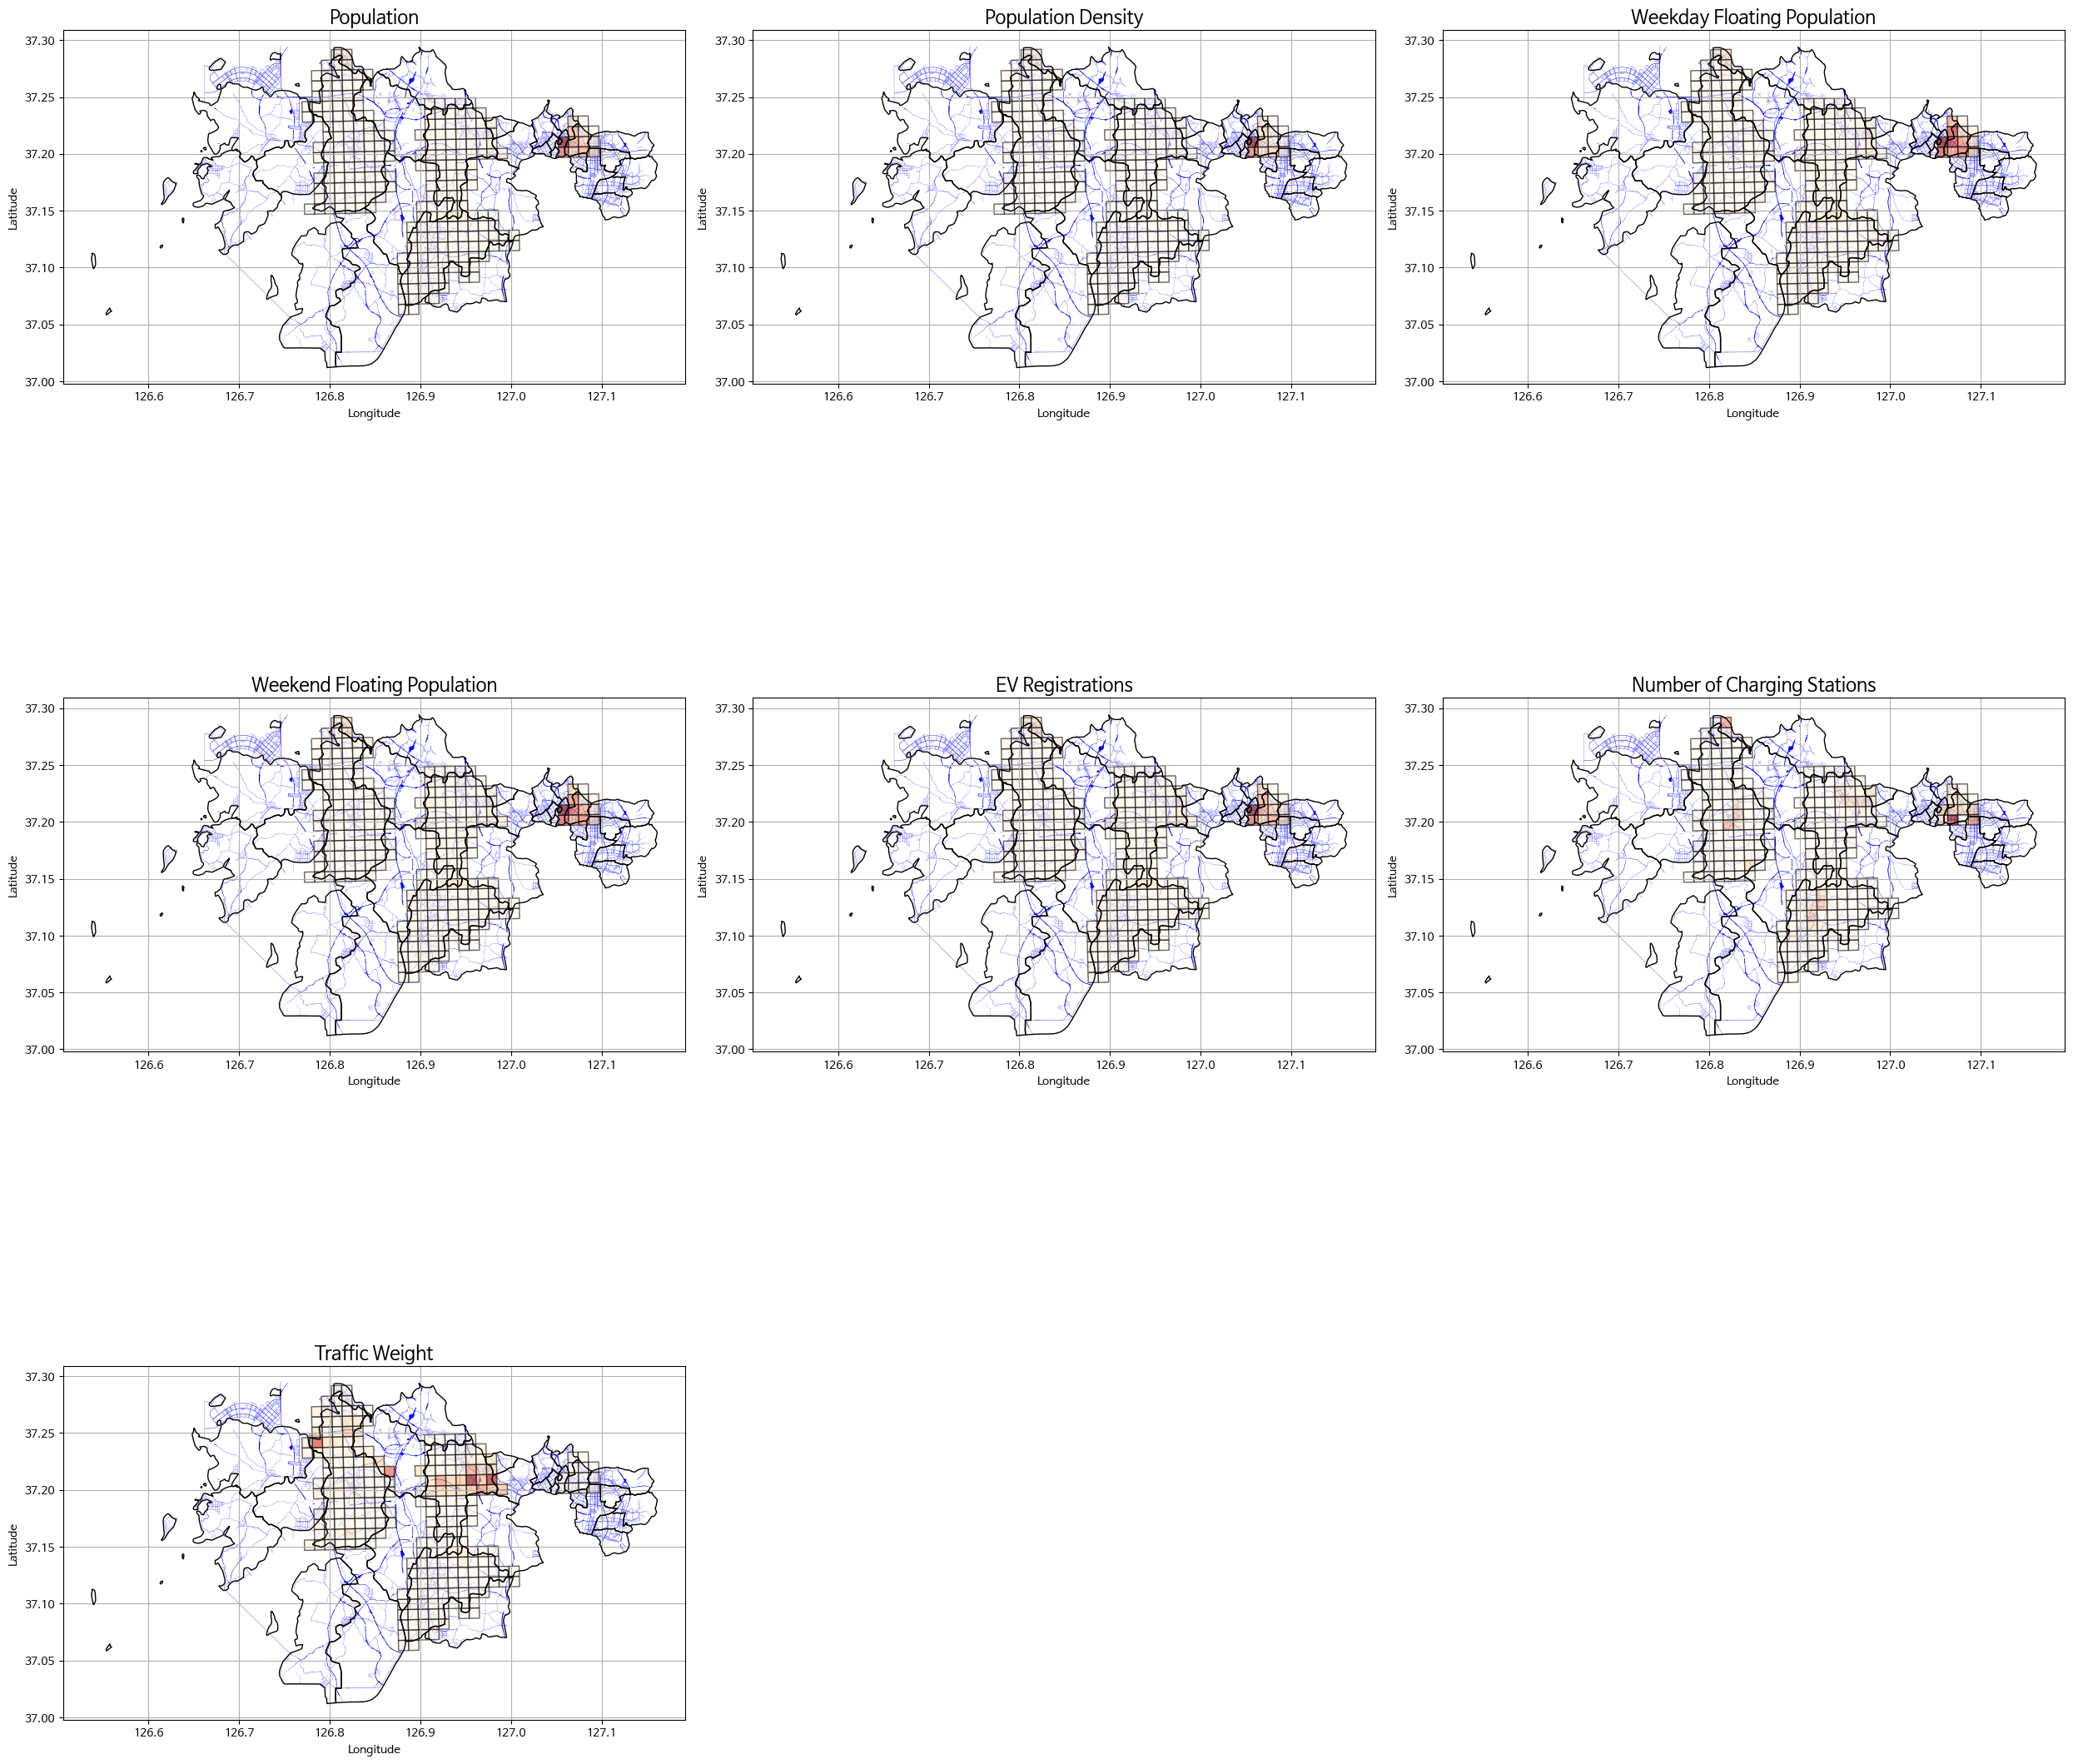

In [87]:
import matplotlib.pyplot as plt

# 시각화용 figure와 axes 생성 (3x3 그리드로 구성, 마지막 2개는 빈 공간으로 남김)
fig, axes = plt.subplots(3, 3, figsize=(25, 25))

# 전체 그리드에서 사용할 공통 스타일 지정
boundary_color = 'black'
boundary_linewidth = 1.0
road_color = 'blue'
road_linewidth = 0.5
grid_edgecolor = 'black'
alpha_value = 0.6

# 각 특성을 시각화할 컬럼 목록
feature_columns = [
    '인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수',
    '전기차등록대수', '충전소_개수', '최종_가중치_교통량'
]
feature_titles = [
    'Population', 'Population Density', 'Weekday Floating Population',
    'Weekend Floating Population', 'EV Registrations',
    'Number of Charging Stations', 'Traffic Weight'
]

# 행정동 경계 및 도로 데이터를 적절히 좌표계 변환
boundary_gdf = boundary_gdf.to_crs(epsg=4326)
road_gdf = road_gdf.to_crs(epsg=4326)
filtered_grid_dong_final = filtered_grid_dong_final.to_crs(epsg=4326)

# 각 특성에 대해 반복하면서 시각화
for i, (ax, column, title) in enumerate(zip(axes.flat, feature_columns, feature_titles)):
    # 행정동 경계 시각화
    boundary_gdf.boundary.plot(ax=ax, color=boundary_color, linewidth=boundary_linewidth)

    # 도로 시각화
    road_gdf.plot(ax=ax, color=road_color, linewidth=road_linewidth)

    # 그리드 특성 시각화
    filtered_grid_dong_final.plot(
        ax=ax, column=column, cmap='OrRd', legend=False, edgecolor=grid_edgecolor, alpha=alpha_value
    )

    # 그래프 타이틀 설정
    ax.set_title(title, fontsize=16)

    # 레이블 설정 및 그리드 추가
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True)

# 불필요한 빈 subplot 제거
for idx in range(7, 9):
    fig.delaxes(axes.flat[idx])

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()


중복된 grid_id가 발견되었습니다. 중복을 제거합니다.


C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\1243237133.py:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\1243237133.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


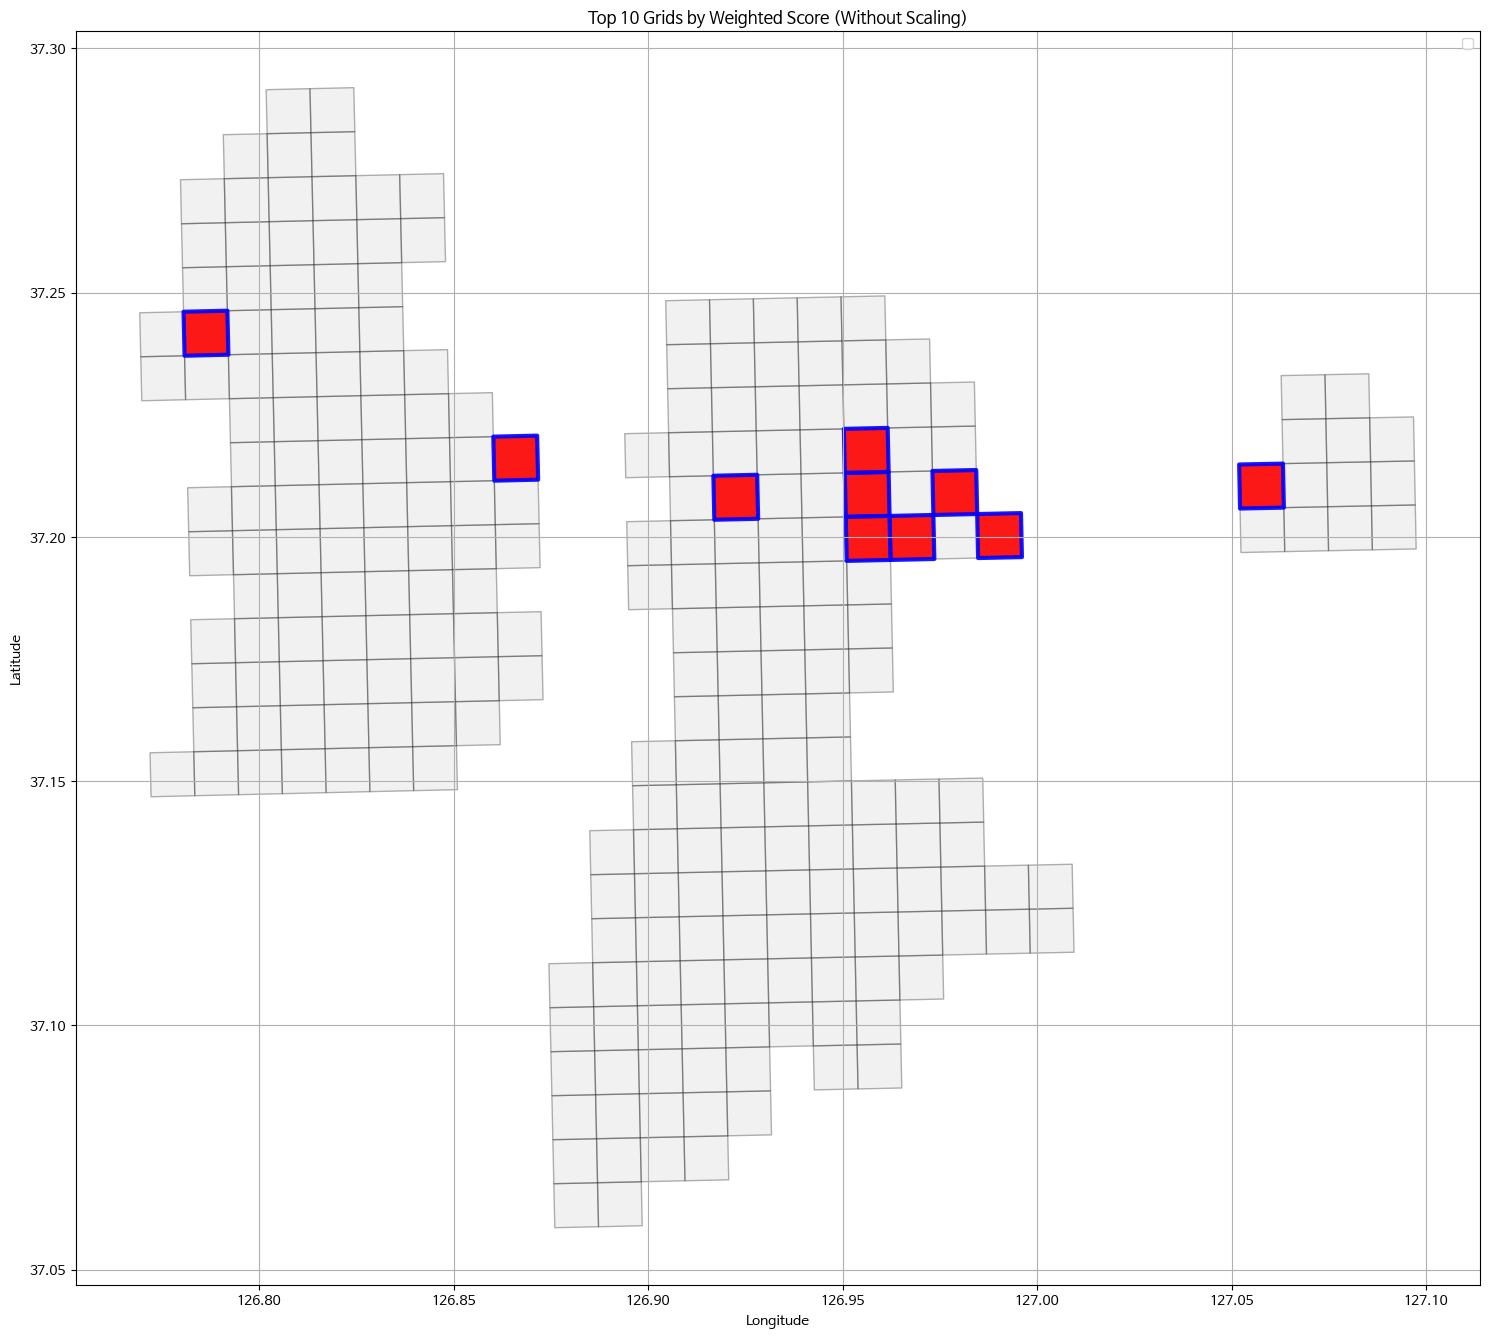

In [88]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 변수 목록과 가중치 정의
feature_columns = [
    '인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수',
    '전기차등록대수', '충전소_개수', '최종_가중치_교통량'
]
weights = {
    '인구수': 3.0,
    '인구밀집도': 2.0,
    '평일평균유동인구수': 2.0,
    '주말평균유동인구수': 2.0,
    '전기차등록대수': 3.0,
    '충전소_개수': 0.5,
    '최종_가중치_교통량': 0.5
}

# 결측치 0으로 채운 후 가중치 적용하여 점수 계산
filtered_grid_dong_final = filtered_grid_dong_final.copy()
filtered_grid_dong_final['종합_점수'] = 0
for column in feature_columns:
    filtered_grid_dong_final[column] = filtered_grid_dong_final[column].fillna(0)  # 결측치를 0으로 채움
    filtered_grid_dong_final['종합_점수'] += filtered_grid_dong_final[column] * weights[column]

# 중복된 grid_id 확인 및 제거
if filtered_grid_dong_final['grid_id'].duplicated().any():
    print("중복된 grid_id가 발견되었습니다. 중복을 제거합니다.")
    filtered_grid_dong_final = filtered_grid_dong_final.drop_duplicates(subset='grid_id')

# 종합 점수가 높은 상위 10개 그리드 추출
top_grids = filtered_grid_dong_final.nlargest(10, '종합_점수')

# 시각화
plt.figure(figsize=(15, 15))
ax = plt.gca()

# 전체 그리드 시각화 (배경으로 표시)
filtered_grid_dong_final.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3)

# 상위 10개 그리드 시각화 (강조하여 표시)
top_grids.plot(ax=ax, color='red', edgecolor='blue', linewidth=3, alpha=0.9, label='Top 10 Grids')

# 그래프 설정
plt.title("Top 10 Grids by Weighted Score (Without Scaling)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [89]:
# 스케일링 적용 전 feature_columns에 대해 결측치와 고유값 확인
print("컬럼별 결측치 개수:")
print(filtered_grid_dong_final[feature_columns].isna().sum())
print("\n컬럼별 고유값 개수:")
print(filtered_grid_dong_final[feature_columns].nunique())

컬럼별 결측치 개수:
인구수           0
인구밀집도         0
평일평균유동인구수     0
주말평균유동인구수     0
전기차등록대수       0
충전소_개수        0
최종_가중치_교통량    0
dtype: int64

컬럼별 고유값 개수:
인구수           169
인구밀집도         169
평일평균유동인구수     169
주말평균유동인구수     169
전기차등록대수       169
충전소_개수         52
최종_가중치_교통량    143
dtype: int64


In [90]:
filtered_grid_dong_final[filtered_grid_dong_final['종합_점수'].isnull()]

,geometry,grid_id,adm_nm,adm_cd2,sgg,sido,sidonm,sggnm,adm_cd,인구수,인구밀집도,평일평균유동인구수,주말평균유동인구수,전기차등록대수,충전소_개수,최종_가중치_교통량,종합_점수


In [91]:
import folium

# 좌표계를 EPSG:4326으로 변환 (Folium에서 위도/경도를 사용)
filtered_grid_dong_final = filtered_grid_dong_final.to_crs(epsg=4326)
top_grids = top_grids.to_crs(epsg=4326)

# 지도 중심 설정 (상위 10개 그리드의 중심)
map_center = [top_grids.geometry.centroid.y.mean(), top_grids.geometry.centroid.x.mean()]
top_grids_map = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

# 상위 10개 그리드를 GeoJSON으로 추가
folium.GeoJson(
    data=top_grids,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.6
    }
).add_to(top_grids_map)

# 각 그리드의 중심에 grid_id와 종합_점수 표시
for _, row in top_grids.iterrows():
    centroid = row['geometry'].centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(html=f"<div style='font-size: 8pt; color: black;'>"
                                 f"{row['grid_id']}<br>Score: {row['종합_점수']:.2f}</div>")
    ).add_to(top_grids_map)

# Folium 지도 출력
top_grids_map


C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\2995304669.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  map_center = [top_grids.geometry.centroid.y.mean(), top_grids.geometry.centroid.x.mean()]


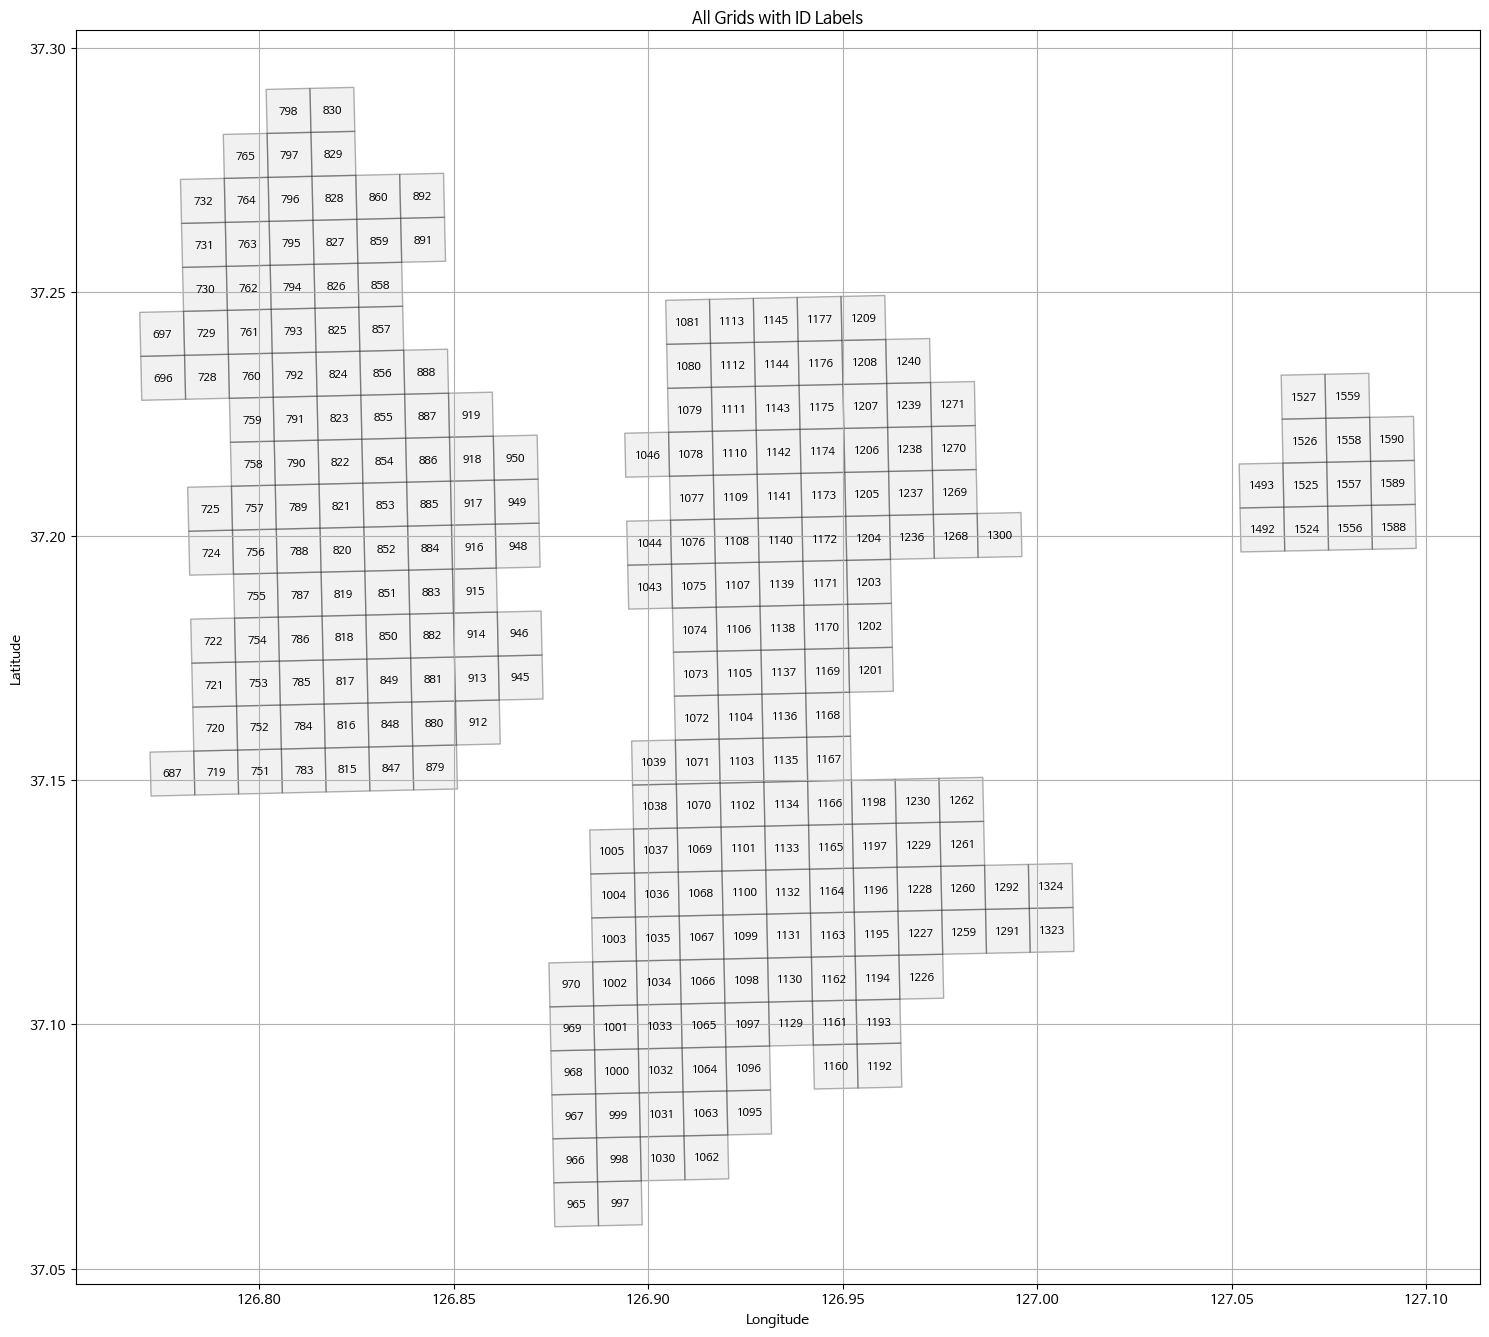

In [92]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 변수 목록과 가중치 정의
feature_columns = [
    '인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수',
    '전기차등록대수', '충전소_개수', '최종_가중치_교통량'
]
weights = {
    '인구수': 0.2,
    '인구밀집도': 0.2,
    '평일평균유동인구수': 0.3,
    '주말평균유동인구수': 0.3,
    '전기차등록대수': 0.3,
    '충전소_개수': 0.2,  # 충전소 개수는 역으로 처리할 예정
    '최종_가중치_교통량': 0.271
}

# 데이터프레임에서 표준화할 부분 추출
features_df = filtered_grid_dong_final[feature_columns]

# Min-Max 스케일링 (표준화) 적용
scaler = MinMaxScaler()
features_normalized = scaler.fit_transform(features_df)

# 표준화된 데이터를 데이터프레임으로 변환
features_normalized_df = pd.DataFrame(features_normalized, columns=feature_columns)

# 충전소 개수에 대한 역 표준화 처리 (1 - 표준화된 값)
features_normalized_df['충전소_개수'] = 1 - features_normalized_df['충전소_개수']

# 표준화된 데이터에 가중치를 적용하여 점수 계산
filtered_grid_dong_final['종합_점수'] = 0  # 초기화
for column in feature_columns:
    filtered_grid_dong_final['종합_점수'] += features_normalized_df[column] * weights[column]

# 전체 그리드 시각화
plt.figure(figsize=(15, 15))
ax = plt.gca()

# 전체 그리드 시각화 (배경으로 표시)
filtered_grid_dong_final.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3)

# 각 그리드 ID를 사각형 안에 표시 (전체 그리드)
for idx, row in filtered_grid_dong_final.iterrows():
    centroid = row['geometry'].centroid  # 각 그리드의 중심점 좌표 계산
    ax.text(centroid.x, centroid.y, str(row['grid_id']), ha='center', va='center', fontsize=8, color='black')

# 그래프 설정
plt.title("All Grids with ID Labels")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [93]:
import folium

# 중심 좌표 설정 (여기서는 데이터의 중심으로 설정)
map_center = [filtered_grid_dong_final.geometry.centroid.y.mean(), filtered_grid_dong_final.geometry.centroid.x.mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

# GeoDataFrame을 GeoJSON으로 추가
folium.GeoJson(
    data=filtered_grid_dong_final,
    style_function=lambda x: {
        'fillColor': 'lightgray',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.3
    }
).add_to(m)

# 각 그리드의 중심에 grid_id를 표시
for _, row in filtered_grid_dong_final.iterrows():
    centroid = row['geometry'].centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(html=f"<div style='font-size: 8pt; color: black;'>{row['grid_id']}</div>")
    ).add_to(m)

# HTML 파일로 저장
output_path = r"C:\Users\SEUNGJUN\project_file\project_file\contentgrid_map_with_ids.html"
m.save(output_path)

output_path


C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3061635376.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  map_center = [filtered_grid_dong_final.geometry.centroid.y.mean(), filtered_grid_dong_final.geometry.centroid.x.mean()]


'C:\\Users\\SEUNGJUN\\project_file\\project_file\\contentgrid_map_with_ids.html'

In [97]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

# 변수 목록과 가중치 정의
feature_columns = [
    '인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수',
    '전기차등록대수', '충전소_개수', '최종_가중치_교통량'
]
weights = {
    '인구수': 0.2,
    '인구밀집도': 0.2,
    '평일평균유동인구수': 0.2,
    '주말평균유동인구수': 0.2,
    '전기차등록대수': 0.2,
    '충전소_개수': 0.2,  # 충전소 개수는 역으로 처리할 예정
    '최종_가중치_교통량': 0.2
}

# 데이터프레임에서 표준화할 부분 추출
features_df = filtered_grid_dong_final[feature_columns]


# Min-Max 스케일링 (표준화) 적용
scaler = MinMaxScaler()
features_normalized = scaler.fit_transform(features_df)

# 표준화된 데이터를 데이터프레임으로 변환
features_normalized_df = pd.DataFrame(features_normalized, columns=feature_columns)

# 충전소 개수에 대한 역 표준화 처리 (1 - 표준화된 값)
features_normalized_df['충전소_개수'] = 1 - features_normalized_df['충전소_개수']

# 표준화된 데이터에 가중치를 적용하여 점수 계산
filtered_grid_dong_final = filtered_grid_dong_final.copy()  # 원본을 보존하기 위해 복사
filtered_grid_dong_final['종합_점수'] = 0  # 초기화
for column in feature_columns:
    filtered_grid_dong_final['종합_점수'] += features_normalized_df[column] * weights[column]

# 중복된 grid_id 확인 및 제거
if filtered_grid_dong_final['grid_id'].duplicated().any():
    print("중복된 grid_id가 발견되었습니다. 중복을 제거합니다.")
    filtered_grid_dong_final = filtered_grid_dong_final.drop_duplicates(subset='grid_id')

# 결과 출력
print(filtered_grid_dong_final[['grid_id', '종합_점수']].head())

# 종합 점수가 높은 순으로 상위 10개 그리드 추출
top_grids = filtered_grid_dong_final.nlargest(10, '종합_점수')

print("종합 점수가 가장 높은 상위 10개 그리드:")
print(top_grids[['grid_id', '종합_점수']])

# folium을 사용하여 상위 10개 그리드를 지도에 시각화
# folium 지도 생성 (중심을 평균으로 설정)
center_lat = top_grids.geometry.centroid.y.mean()
center_lon = top_grids.geometry.centroid.x.mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# 상위 10개 그리드를 지도에 추가
for _, row in top_grids.iterrows():
    geo_json = folium.GeoJson(data=row['geometry'],
                              style_function=lambda x: {'fillColor': 'red', 'color': 'blue', 'weight': 2, 'fillOpacity': 0.5})
    geo_json.add_to(m)

# 지도 출력
m

   grid_id     종합_점수
0      687  0.207553
1      696  0.222095
2      697  0.229656
3      719  0.221776
4      720  0.206326
종합 점수가 가장 높은 상위 10개 그리드:
     grid_id     종합_점수
242     1300  1.138274
241     1292  0.830572
247     1524  0.702915
244     1324  0.661516
245     1492  0.654740
248     1525  0.484476
233     1260  0.458632
213     1201  0.424393
246     1493  0.419145
59       829  0.364690


C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3686904354.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = top_grids.geometry.centroid.y.mean()
C:\Users\SEUNGJUN\AppData\Local\Temp\ipykernel_25104\3686904354.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = top_grids.geometry.centroid.x.mean()


In [100]:
import pandas as pd

# features: 사용한 분석 변수 리스트
features = ['인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수', '전기차 등록대수']
# df_finally: 행정동별 데이터 + '클러스터' 컬럼 포함

cluster_stats = df_finally.groupby('클러스터')[features].mean().round(2)
print(cluster_stats)

           인구수  인구밀집도  평일평균유동인구수  주말평균유동인구수  전기차 등록대수
클러스터                                                 
0     45079.50   0.01    4525.35    4253.85    530.62
1     89235.00   0.00   10488.77   10310.47   1323.50
2     32080.00   0.02    2505.21    2687.06    335.00
3     11182.25   0.00    1784.83    1502.79    235.00
4     52804.50   0.01    8021.88    7169.35    731.00


In [101]:
for c in sorted(df_finally['클러스터'].unique()):
    print(f"[클러스터 {c}]")
    print(df_finally[df_finally['클러스터'] == c]['행정구역'].values)

[클러스터 0]
['경기도 화성시 동탄4동' '경기도 화성시 동탄5동' '경기도 화성시 동탄6동' '경기도 화성시 동탄7동'
 '경기도 화성시 동탄8동' '경기도 화성시 동탄9동' '경기도 화성시 반월동' '경기도 화성시 진안동']
[클러스터 1]
['경기도 화성시 봉담읍' '경기도 화성시 향남읍']
[클러스터 2]
['경기도 화성시 동탄2동' '경기도 화성시 동탄3동' '경기도 화성시 병점1동' '경기도 화성시 병점2동' '경기도 화성시 새솔동']
[클러스터 3]
['경기도 화성시 기배동' '경기도 화성시 마도면' '경기도 화성시 매송면' '경기도 화성시 비봉면' '경기도 화성시 서신면'
 '경기도 화성시 송산면' '경기도 화성시 양감면' '경기도 화성시 우정읍' '경기도 화성시 장안면' '경기도 화성시 정남면'
 '경기도 화성시 팔탄면' '경기도 화성시 화산동']
[클러스터 4]
['경기도 화성시 남양읍' '경기도 화성시 동탄1동']


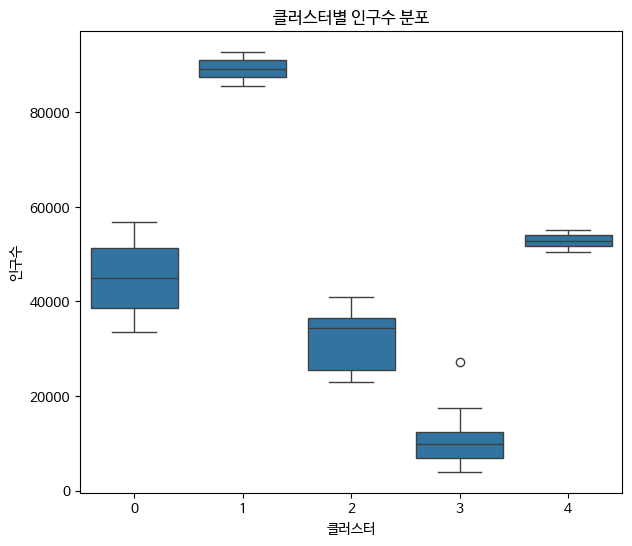

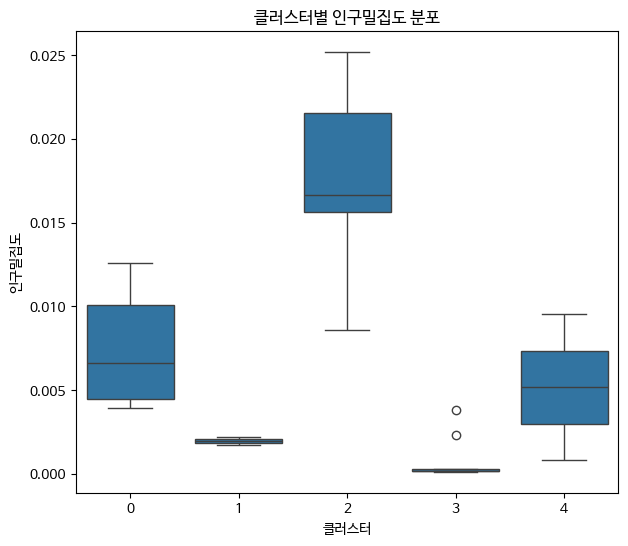

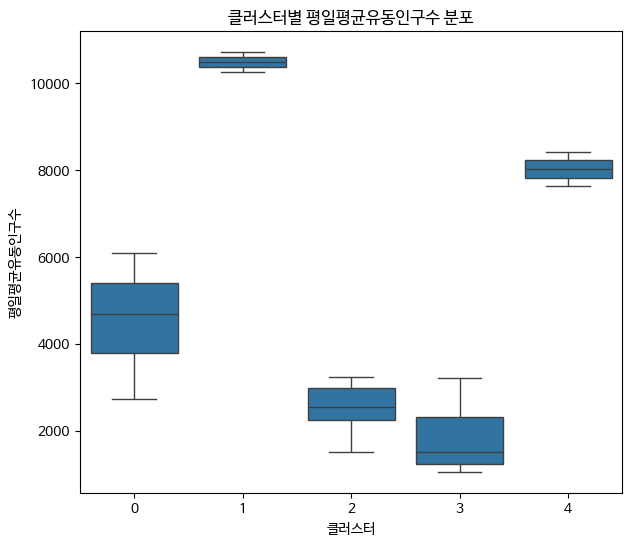

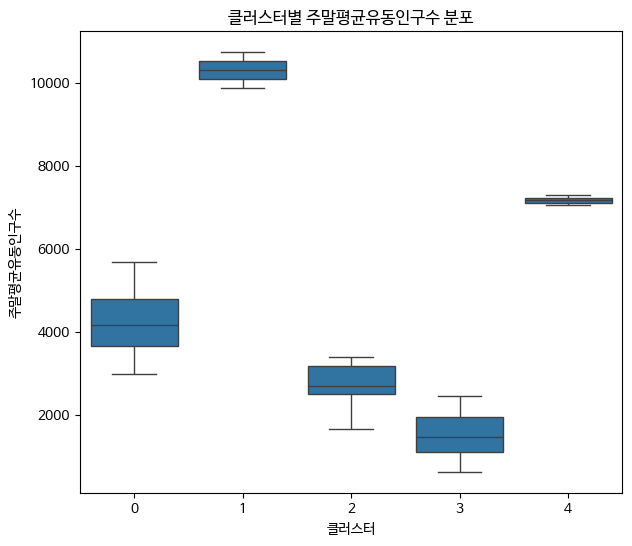

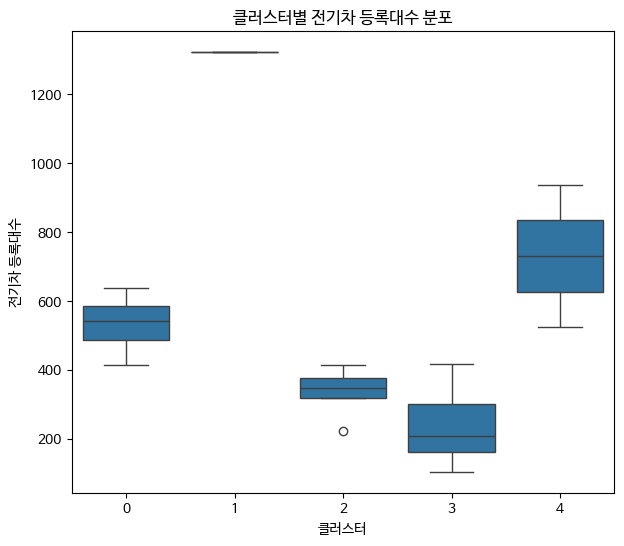

In [105]:
features = ['인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수', '전기차 등록대수']

for feat in features:
    plt.figure(figsize=(7,6))
    sns.boxplot(data=df_finally, x='클러스터', y=feat)
    plt.title(f'클러스터별 {feat} 분포')
    plt.xlabel('클러스터')
    plt.ylabel(feat)
    plt.show()

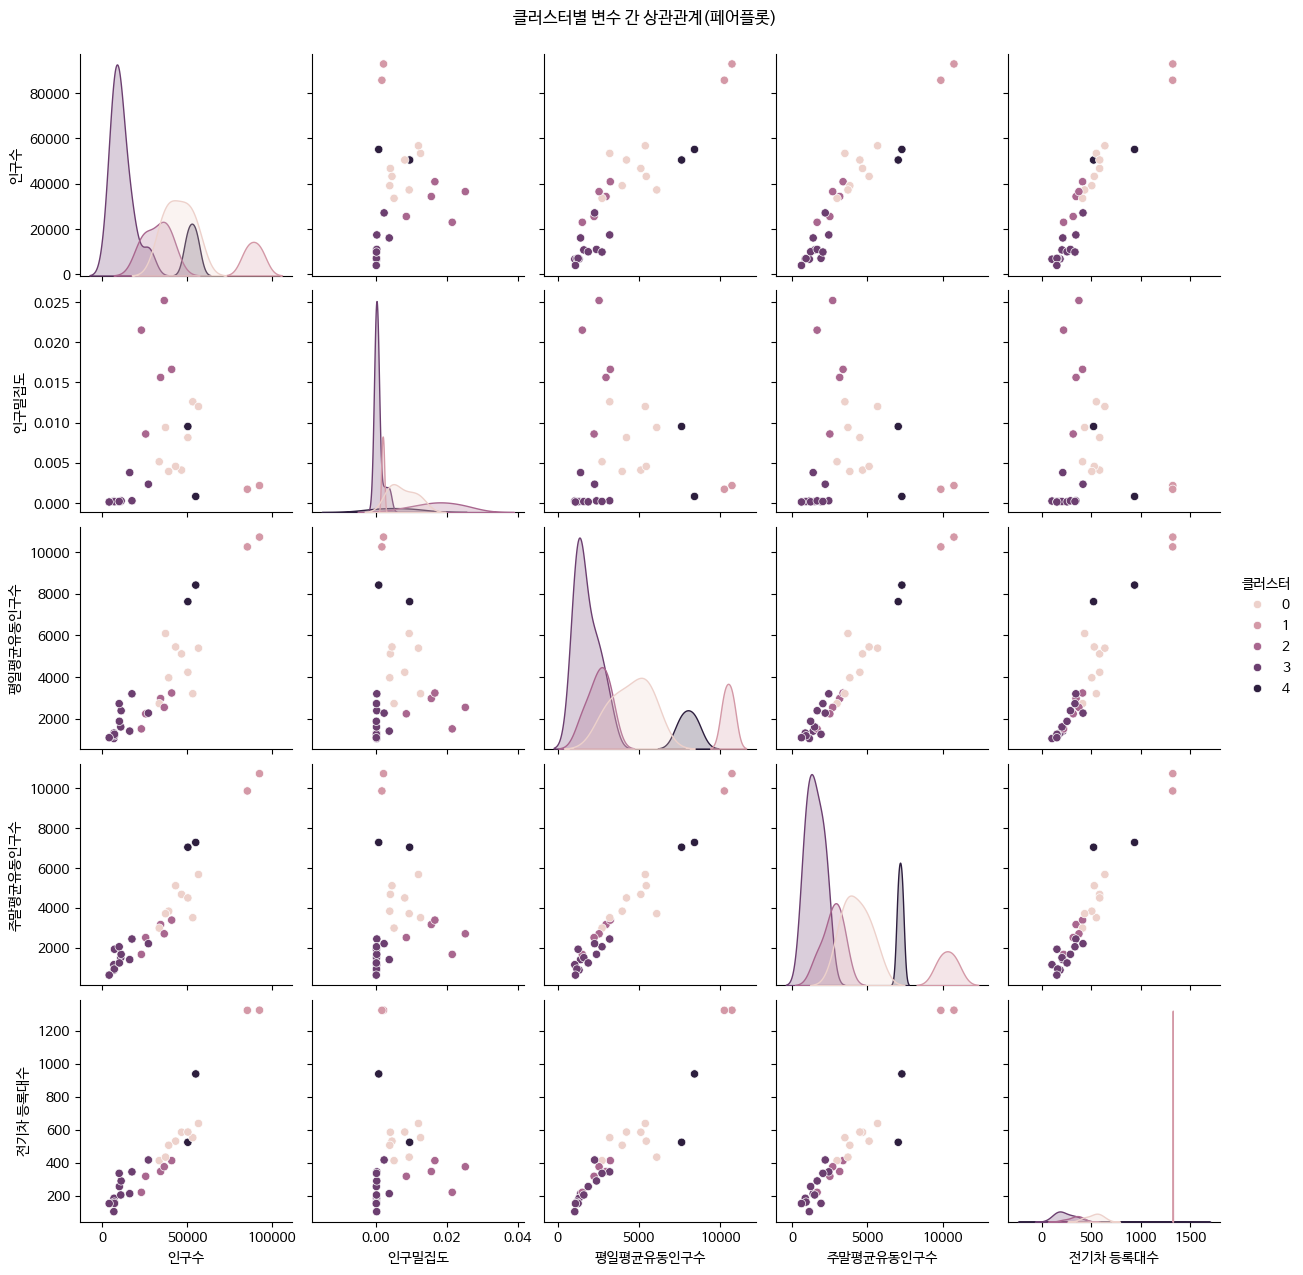

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_finally, hue='클러스터', vars=['인구수','인구밀집도','평일평균유동인구수','주말평균유동인구수','전기차 등록대수'])
plt.suptitle('클러스터별 변수 간 상관관계(페어플롯)', y=1.02)
plt.show()

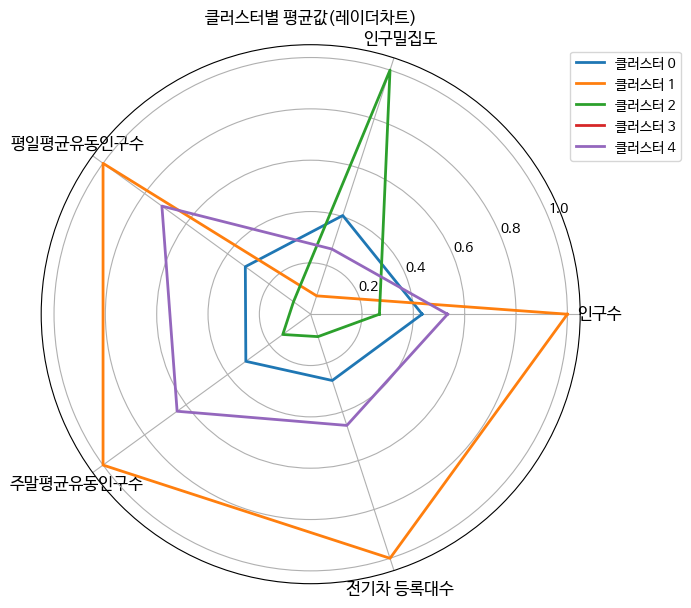

In [108]:
import matplotlib.pyplot as plt
import numpy as np

features = ['인구수', '인구밀집도', '평일평균유동인구수', '주말평균유동인구수', '전기차 등록대수']
cluster_stats = df_finally.groupby('클러스터')[features].mean()

# 표준화(0~1)
from sklearn.preprocessing import MinMaxScaler
cluster_stats_norm = MinMaxScaler().fit_transform(cluster_stats)
labels = features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
for i, row in enumerate(cluster_stats_norm):
    values = row.tolist()
    values += values[:1]  # 닫기
    plt.polar(angles, values, label=f'클러스터 {i}', linewidth=2)

plt.xticks(angles[:-1], labels, fontsize=12)
plt.title('클러스터별 평균값(레이더차트)')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()
